# Text Analysis: 50 yrs. of Magazine Issues
Analysis of 50 years of magazine issues to discover trends in topics addressed over time.

**Author:** [Ryan Parker](https://github.com/rparkr).

**Data source:** Data scraped from magazines of The Church of Jesus Christ of Latter-day Saints from 1971-2021. Starting point: [Church Magazines](https://www.churchofjesuschrist.org/study/magazines?lang=eng).

**Objective**: understand trends in topics addressed through the content of four magazines produced by [The Church of Jesus Christ of Latter-day Saints](https://churchofjesuschrist.org).

In addition to collecting data, I'll analyze the data and implement various machine learning algorithms to understand the data, uncover insights, and make predictions.

## Steps
1. Data collection: Gather data through web scraping, then lightly process it and save it to .csv files.
2. <strong><span style="color:rgb(82, 191, 127)">Topic modeling (this notebook)</strong></span>: assign a topic to each document (article) and label the topics, then append the topic label as a new feature (column) in the dataset.
3. Data augmentation: modify and add additional features (columns) to the dataset to enhance its analysis.
4. Analysis: explore the dataset through visualization, and make predictions using supervised and unsupervised machine learing algorithms.


# Topic modeling
Here, I predict a topic for each article in the dataset based on 158 topics curated from the [Gospel Topics](https://www.churchofjesuschrist.org/study/manual/gospel-topics) articles on [ChurchOfJesusChrist.org](https://www.churchofjesuschrist.org).

This notebook assumes that the .csv files created by the Data Collection notebook exist and are saved in the `data/` directory (relative to where this notebook is saved). In particular, it relies on:
- `data/article_data.csv`
- `data/article_text.csv`
- `data/topics_gt_mod.csv`

... and, optionally:
```python
# Alternative topic lists
'data/topics_tf.csv'    # 223 topics; up-to-date, but uncurated and many related topics
'data/topics_gt.csv'    # 108 topics; last updated in 2004
```

## Methodology

In natural language processing (NLP) parlance, each article is a _document_. I implement two methods to classify each document as one of 158 possible categories, or topics.

**Topic assignment**

The first method is my own naïve approach that uses matrix-multiplication to score how similar each document is to each topic. The resulting matrix has n_documents rows by n_topics columns, where each column is the similarity score of a particular topic to each document. The topic chosen for each document is the one with the highest similarity score. 

The second method uses Scikit-Learn's Non-Negative Matrix Factorization (`NMF`) algorithm, which performs very well, but takes longer to process -- it iterates over the dataset and creates two non-negative matrices: a topic-term matrix (called _H_ and accessed with `nmf_model.components_`) and a document-topic matrix (called _W_) whose product approximates the doc-term matrix _X_ that was passed to it during fitting. The function minimizes the difference between $H \times W$ and $X$, where the loss, that difference, is called _violation_. Each iteration, the algorithm alternates between adjusting _H_ and _W_.

**Labeling each topic**

For both methods, I automatically assign a label to the topic thanks to the topic articles I scraped from Gospel Topics, using similarity scores returned by matrix multiplication. In the naïve method, the assigned topic is just the argmax across the columns for each row in the doc-topic matrix. The index value returned by argmax accesses the topic label by its index.

For the `NMF` method, I multiply the topic-terms matrix computed by NMF with the transposed doc-terms matrix (where the topic articles are documents) to create a topic-topic matrix of size n_topics rows by n_topics columns, where the rows are topics computed by NMF and each column is the similarity score of an article topic (a label) with each of the computed topics. The label assigned to each computed topic (i.e., each row) is the argmax across the columns, which returns an index that I use to access the label name (that is, the topic name from the topic articles). Note that this collapses some computed topics by assigning them the same label. Thus, the NMF version will likely have fewer total labeled topics than the naïve method.

**Text preparation**

Prior to computing the topics, I vectorize the documents to create a doc-terms matrix of size n_docs rows by n_terms columns, where each column is the normalized occurence of a term (n-gram) in each document. Importantly, the topic articles are included with the document articles when creating the doc-terms matrix. This means that each topic article will be treated as its own document. I append the topic articles to the end of the doc-terms matrix so they can be easily removed for other operations (matrix-multiplication) in later computations.

For efficiency, Scikit-Learn creates this doc-terms matrix as a `scipy` _sparse_ matrix, since the majority of its values are `0`s (e.g., if there are 50,000 documents and 100,000 terms, each document will likely have a small fraction of the total terms present in the entire corpus, so most of the values in any row will be 0s).

**Background and more info**

I arrived at the methods above after much experimentation with different approaches. You can see my experiments in the "Experiment: ..." sections at the bottom of this notebook.

## Import packages required for this section

**Explanation of `sklearn` imports**
- `TfidfVectorizer`: Convert documents to vectors representing the number of times a normalized word or n-gram appeared in each document where words are normalized by Term-frequency x Inverse-document-frequency
- `NMF` and `MiniBatchNMF`: Assign topics to documents after the documents have been processed and normalized (e.g., by `TfidfVectorizer`). Time complexity increases in polynomial time with respect to the number of inputs, so the `MiniBatchNMF` can perform much faster for large datasets since it uses a default batch size of 1,024 documents compared to the entire set of documents.

In [1]:
# Built-in packages
import re                       # text-based pattern matching
import time                     # measure code execution time
import unicodedata              # Unicode character reference (database on character properties)
                                # for normalizing characters. See also unicodedata2: https://pypi.org/project/unicodedata2/

# Third-party packages
import numpy as np                # array-based data storage and computation
import pandas as pd               # tabular data analysis
pd.options.display.precision = 3  # Show 3 decimal places of precision in DataFrames

# Scikit-Learn classes   
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, MiniBatchNMF

# set_config: Disable HTML display of sklearn objects;
# this way, the text representation is returned
# when an object's __repr__ method is called, like
# when that object is on the last line in a code cell.
from sklearn import set_config
set_config(display='text')

## Doc-terms matrix
Prior to running the topic models, the text must be _vectorized_: converted into a matrix of numbers that can be processed by the algorithms to assign a topic for each document.

After experimenting with multiple approaches, I chose to use Scikit-Learn's `TfidfVectorizer`, which uses Term Frequency x Inverse Document Frequency (TF-IDF) to create a document-terms matrix of n_documents rows by n_terms columns, where terms are n-grams present in the text corpus (i.e., the text of all documents together). TF-IDF is a method of normalizing term frequency counts, where terms are weighed less if they appear in many documents in the corpus, since that means they likely do not differentiate between topics.

### Text pre-processing

Function to normalize text (convert Unicode to ASCII equivalents), convert to lowercase, and remove non-alphabetic characters.

In [2]:
def preprocess_text(orig_str):
    '''lowecase, normalize unicode text to ASCII-equivalent characters,
    and remove punctuation and anything between parentheses.'''
    # unidecode is a third-party package for unicode normaliznig
    # that works with most Latin-looking characters and punctuation.
    # new_str = unidecode.unidecode(orig_str.lower())

    # Replace anything inside parentheses (to remove scripture references, which may skew the dataset
    # towards topics like Doctrine and Covenants)
    new_str = re.sub(pattern=r'\(.+?\)', repl=' ', string=orig_str.lower())

    # unicodedata.normalize is Python's built-in normalizing method. 
    # It fails to convert “” to "" and ‘’ to '', but is good enough 
    # for my purposes since I remove those characters anyways.
    # sklearn's TfidfVectorizer also doesn't remove those characters (or numbers, either).
    new_str = unicodedata.normalize(
        'NFKD',
        new_str
    ).encode(encoding='ascii', errors='ignore').decode()

    # Remove digits and punctuation (and anything else besides lowercase a-z and whitespace)
    new_str = re.sub(pattern=r'[^a-z\s]', repl=' ', string=new_str)
    
    # Replace multiple whitespace chars with a single space
    new_str = re.sub(pattern=r'[\s]{2,}', repl=' ', string=new_str)

    return new_str

### Load data

In [3]:
# Load article text
text_df = pd.read_csv('data/article_text.csv').dropna()
print(f"Loaded article text data ({len(text_df.index):,.0f} articles).")

# Load topics. Can use one of:
# RECOMMENDED ↓
# -------------------------------------------------------------------------------
# data/topics_gt_mod.csv  | newer topical reference, manually modified 
#                           from topics_gt.csv to remove glossary-style topics
#                           and consolidate similar topics. 75 topics.
# --------------------------------------------------------------------------------
# data/topics_gt.csv      | newer topical reference, 223 topics. Updated ca. 2020.
# data/topics_tf.csv      | older topical reference, 108 topics. Updated 2004.
topic_df = pd.read_csv('data/topics_gt_mod.csv')

num_topics = len(topic_df.index)
print(f"Topics loaded. Total number of topics: {num_topics}")

full_data = pd.concat([text_df['text'], topic_df['text']], ignore_index=True)

# Verify that the Series loaded correctly
print(f"full_data Series loaded correctly? -> {len(full_data.index) == len(text_df.index) + len(topic_df.index)}")

Loaded article text data (64,953 articles).
Topics loaded. Total number of topics: 75
full_data Series loaded correctly? -> True


Load `article_data.csv`, where the resulting topics will be saved.

In [5]:
article_data_df = pd.read_csv('data/article_data.csv', low_memory=False)
# Remove articles that don't have text (they're not really articles, after all 😉)
article_has_text = article_data_df.word_count.notna()
trimmed_article_data_df = article_data_df[article_has_text]

print(f"Articles with text from article_data.csv: {len(trimmed_article_data_df.index):,.0f}")
print(f"vs. number of articles in article_text.csv: {len(text_df.index):,.0f}")

Articles with text from article_data.csv: 64,953
vs. number of articles in article_text.csv: 64,953


### Create doc-terms matrix
This is a matrix of n_documents rows by n_terms columns, where each term is an _ngram_. In this analysis, I use individual words—_unigrams_—and two consecutive words—_bigrams_. English stopwords like 'and', 'to', or 'a' are removed, as are any terms that appear only in a single document or that appear in more than 95% of all documents.

Using bigrams greatly increases the total number of terms, but bigrams capture meaning from phrases or word order that is missed by unigrams, so I think it is valuable to include them.

In [6]:
# The range for n-gram terms to include. (1, 1) means unigrams (single words) only.
# (1, 2) means unigrams and bigrams. (2, 2) means bigrams only, etc.
NGRAMS = (1, 2)

# Automatic stopword filtering
MAX_DOC_FREQ = 0.95       # Term cannot be present in over 95% of documents
MIN_DOC_FREQ = 2          # Term must be present in at least 2 documents

# The maximum number of terms that will be used
# MAX_NUM_TERMS = 50_000 

tfidf = TfidfVectorizer(
    # max_features = MAX_NUM_TERMS,
    preprocessor = preprocess_text,
    ngram_range = NGRAMS,
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words = 'english'
)

# Document-terms matrix (dtm) for term-frequency by inverse-document-frequency (TfidfVectorizer).
print("Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...")
t0 = time.perf_counter()

dtm = tfidf.fit_transform(full_data)

print(f"✅ Completed in {time.perf_counter() - t0:,.3f} seconds.")

# Check vocabulary size
print(f"\nNumber of docs by number of terms:\n{dtm.shape}")

# View the size, in bytes, of the doc-to-terms matrix
print(f"Approximate size in memory: {dtm.data.nbytes:,.0f} bytes")

# Check number of terms (ngrams) added to stopwords (usually
# because they appeared in only 1 document).
if len(tfidf.stop_words_) < 100:
    if tfidf.stop_words_ == set():
        print("Default stopwords list used, no new terms added.")
        # Show default stopwords list:
        # print(tf.get_stop_words())
    else:
        print(f"Words added to stopwords list:\n{tfidf.stop_words_}")
else:
    print(f"Number of terms added to stopword list: {len(tfidf.stop_words_):,.0f}")

Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...
✅ Completed in 186.957 seconds.

Number of docs by number of terms:
(65028, 2976912)
Approximate size in memory: 267,390,568 bytes
Number of terms added to stopword list: 4,082,032


Extract the doc-terms matrix for the topics, then normalize by word count, so topics with more words are not weighted any more than topics with fewer words.

This doc-terms matrix for the topics will be used to automatically label topics in both the naive and `NMF` methods.

Although this same matrix could be used for `NMF`, I use a separate version of the doc-terms matrix for `NMF` that has significantly fewer terms to help `NMF` converge faster.

In [7]:
# Get the topic articles from the end of the doc-terms matrix
dtm_labels = dtm[-num_topics: , :]

# Normalize by word count. The .reshape turns the sum into a column vector used in the divide operation
dtm_labels /= dtm_labels.sum(axis=1).reshape(-1, 1)
# More verbose way...
# dtm_labels = dtm_labels / (dtm_labels.sum(axis=1).reshape(-1, 1))

## Naïve topic assignment
To compute topics, I multiply the doc-terms matrix by the transposed topic-terms matrix (which is the doc-terms matrix of the topic articles) and take the argmax of each row.

This method is very fast and surprisingly accurate.

Of course, it is available to me only because I have a fine collection of topic articles to draw from. In the absence of such a resource, I would resort to the Non-Negative Matrix Factorization (NMF) approach below, but I wouldn't have an easy way to assign labels to each topic (two ideas are: 1. find the most influential term for each topic and use that as its label; 2. compare synonyms for the top words in each topic and find a common synonym that can be used as the topic label).

### Assign topic labels to documents

For matrix multiplication, $(m\_rows, n\_cols) \times (n\_rows, p\_cols)$ -> $(m\_rows, p\_cols)$

Assign topic similarity scores for each document. The resulting matrix will have n_documents rows by n_topics columns. Each column holds the simlarity score of that topic with every document. Across each row are the similarity scores of all topics for the given document.

The maximum value for a row represents the topic that is most similar to the document.

In [8]:
# Matrix multiplication using the @ operator.
naive_topic_similarities = dtm[:-num_topics, :] @ dtm_labels.transpose()

# Find the most-similar topic for each document.
# Note that csr_matrix.argmax() returns a 2-D numpy.matrix object.
naive_topic_assignments = naive_topic_similarities.argmax(axis=1)

In [9]:
print(f"Shape of doc-topic matrix using naive method: {naive_topic_similarities.shape}")
print(f"After applying an argmax across the columns: {naive_topic_assignments.shape}")

Shape of doc-topic matrix using naive method: (64953, 75)
After applying an argmax across the columns: (64953, 1)


Add topic names (labels) to the article data. I first create a Series from the indices of the most-simlar topic for each document, then I return the label (topic name) for each index.

In [10]:
naive_topic_label_srs = pd.Series(
    data = np.array(naive_topic_assignments).flatten(), # flatten converts the 2D matrix to a 1D array
    index = trimmed_article_data_df.index,
    name = 'naive_topic'
    ).apply(lambda v: topic_df.at[v, 'topic'])

article_data_df = article_data_df.join(naive_topic_label_srs, how='left')
article_data_df.to_csv('experiments/article_data_naive_topic.csv', index=False)

In [13]:
# View a sample of assigned topics.
article_data_df[
    ['magazine', 'year', 'month', 'title', 'naive_topic']
].sample(n=10, random_state=0)

,magazine,year,month,title,naive_topic
34384,Ensign,1981,November,“Except a Man Be Born Again”,Book of Mormon
31308,Ensign,1987,January,First Year in Office Marked for President Benson,Book of Mormon
13968,Liahona,1987,February,“Why Would They Need Another Mormon in Salt La...,Teaching the Gospel
22534,Ensign,2006,May,All Men Everywhere,Book of Mormon
32886,Ensign,1984,April,LDS Scene,Emergency Preparedness
61465,Friend,1994,July,Music Match,Book of Mormon
22190,Ensign,2007,July,Church Teaching Life-Saving Techniques to Heal...,Education
6871,Liahona,2010,January,NaN,NaN
65603,Friend,1979,August,Tangled Sentences,Word of Wisdom
60419,Friend,1997,February,Articles of Faith Word Maze 3,Eternal Life


### Topic prevalence
Let's see which topics are assigned most frequently.

In [43]:
df_naive_topic_ranking = pd.merge(
    topic_df[['topic', 'text']],
    article_data_df.naive_topic.value_counts().rename('article_count'),
    how='left',
    left_on='topic',
    right_index=True
)

# Add word count information for each topic
df_naive_topic_ranking['word_count'] = df_naive_topic_ranking.text.apply(lambda v: len(str(v).split()))

df_naive_topic_ranking.sort_values(by=['article_count', 'word_count'], ascending=[False, True])

,topic,text,article_count,word_count
24,Family History,Family History: Family history is discovering ...,3787,231
42,Love,"Love: Love is a feeling of deep devotion, conc...",3337,144
6,Book of Mormon,Book of Mormon: What Is the Book of Mormon? Th...,3254,469
9,Christmas,Christmas: “When we keep the spirit of Christm...,2810,279
27,Gospel,Gospel: The gospel is our Heavenly Father’s pl...,2730,167
...,...,...,...,...
13,Covenant,Covenant: A covenant is a sacred agreement bet...,122,1230
8,Chastity,Chastity: Chastity is sexual purity. Those who...,122,1437
15,Diversity and Unity in The Church of Jesus Chr...,Diversity and Unity in The Church of Jesus Chr...,106,5139
21,Faith in Jesus Christ,Faith in Jesus Christ: The Apostle Paul taught...,59,4866


There is a strong negative correlation between the word count of a topic and the count of articles assigned to that topic. That is, longer topics (by word count) will have fewer articles assigned to them. This is likely related to the way `TfidfVectorizer` weights terms, along with the normalizing I apply to the topics matrix (i.e., dividing the terms matrix by the word count).

In [44]:
df_naive_topic_ranking[['article_count', 'word_count']].corr()

,article_count,word_count
article_count,1.000,-0.314
word_count,-0.314,1.000


In [45]:
df_naive_topic_ranking[['topic', 'article_count', 'word_count']].to_csv('experiments/naive_method_topic_and_word_counts.csv', index=False)

## `sklearn` method: NMF

**Notes**
- Setting `verbose=1` on an NMF model will print the model's loss each iteration. Can be helpful to notice its improvement over time.
- I used the default settings for NMF except I set `init='nndsvda'`, which is the initialization strategy used for MiniBatchNMF, and is the setting that [Scikit-Learn used in the example code](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html) comparing NMF to MiniBatchNMF and LDA.
- I fit the model with the topics' doc-term matrix included, which (likely) helps the models assign categories since they can access the full array of words, compared to if I had filtered to include only the documents from the doc-terms matrix but not the topics.

### Doc-terms matrix
This is a modified version compared to what I used in the naïve method above because `NMF` is much more memory and computation intensive, so it helps to work with a smaller dataset.

Here, I use a sample of the full article data to create a vocabulary (i.e., through creating a doc-terms matrix) and then fit a NMF model to that doc-terms matrix.

I then create a doc-terms matrix for the entire article data, but limited to the vocabulary from the sample, which ignores any other terms (words, bigrams) in the full dataset that were not present in the sample.

Finally, I apply the `.transform()` method of the fit `NMF` model on the _full dataset_ to assign topics to each document.

In [14]:
# Take a sample of 1,000 documents
sample_data = text_df['text'].sample(n=1000)
# Add to that sample the topics (topic articles)
sample_data = pd.concat([sample_data, topic_df['text']], ignore_index=True)

Create doc-terms matrix for the sample.

In [15]:
# The range for n-gram terms to include. (1, 1) means unigrams (single words) only.
# (1, 2) means unigrams and bigrams. (2, 2) means bigrams only, etc.
NGRAMS = (1, 2)

# Automatic stopword filtering
MAX_DOC_FREQ = 0.95       # Term cannot be present in over 95% of documents
MIN_DOC_FREQ = 2          # Term must be present in at least 2 documents

# The maximum number of terms that will be used
# MAX_NUM_TERMS = 50_000 

tfidf_sample = TfidfVectorizer(
    # max_features = MAX_NUM_TERMS,
    preprocessor = preprocess_text,
    ngram_range = NGRAMS,
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words = 'english'
)

# Document-terms matrix (dtm) for term-frequency by
# inverse-document-frequency (TfidfVectorizer).
print("Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...")
t0 = time.perf_counter()

dtm_sample = tfidf_sample.fit_transform(sample_data)    # ⭐--> CHANGED FROM ABOVE SECTION. Uses sample_data rather than full_data

print(f"✅ Completed in {time.perf_counter() - t0:.3f} seconds.")

# Check vocabulary size
print(f"\nNumber of docs by number of terms:\n{dtm_sample.shape}")

# View the size, in bytes, of the doc-to-terms matrix
print(f"Approximate size in memory: {dtm_sample.data.nbytes:,.0f} bytes")

# Check number of terms (ngrams) added to stopwords (usually
# because they appeared in only 1 document).
if len(tfidf_sample.stop_words_) < 100:
    if tfidf_sample.stop_words_ == set():
        print("Default stopwords list used, no new terms added.")
        # Show default stopwords list:
        # print(tf.get_stop_words())
    else:
        print(f"Words added to stopwords list:\n{tfidf_sample.stop_words_}")
else:
    print(f"Number of terms added to stopword list: {len(tfidf_sample.stop_words_):,.0f}")

Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...
✅ Completed in 5.978 seconds.

Number of docs by number of terms:
(1075, 50189)
Approximate size in memory: 2,884,248 bytes
Number of terms added to stopword list: 270,075


Extract the doc-terms matrix for the topics, then normalize by word count, so topics with more words are not weighted any more than topics with fewer words.

This doc-terms matrix for the topics will be used to automatically label topics in the `NMF` method.

It differs from the doc-terms matrix in the naive version only in the number of terms (columns), since I created this doc-terms matrix from a sample of the full dataset, rather than the full dataset.

In [16]:
# Get the bottom part of the doc-terms matrix, with the topic articles
dtm_labels_sample = dtm_sample[-num_topics: , :]

# Normalize by word count. The .reshape turns the sum into a column vector used in the divide operation
dtm_labels_sample /= dtm_labels_sample.sum(axis=1).reshape(-1, 1)
# More verbose way...
# dtm_labels_sample = dtm_labels_sample / (dtm_labels_sample.sum(axis=1).reshape(-1, 1))

Create the doc-terms matrix for the entire dataset using the vocabulary from the sample.

In [18]:
tfidf_complete = TfidfVectorizer(
    preprocessor = preprocess_text,
    ngram_range = NGRAMS,
    vocabulary = tfidf_sample.vocabulary_  # --> Use vocabulary from prior fit, 
                                           #     ignoring max_df and min_df parameters.
)

print("Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...")
t0 = time.perf_counter()

dtm_complete = tfidf_complete.fit_transform(full_data)

print(f"✅ Completed in {time.perf_counter() - t0:.3f} seconds.")

# Check vocabulary size
print(f"Number of docs by number of terms:\n{dtm_complete.shape}")

# View the size, in bytes, of the doc-to-terms matrix
print(f"Approximate size in memory: {dtm_complete.data.nbytes:,.0f} bytes")

Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...
✅ Completed in 171.837 seconds.
Number of docs by number of terms:
(65028, 49304)
Approximate size in memory: 127,474,544 bytes


### Set up model

Note that the commented-out parameters are optional. I took them from the [Scikit-Learn example code](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html) comparing NMF to MiniBatchNMF and LDA.

In [19]:
# nmf = MiniBatchNMF(
#     n_components = num_topics,
#     # random_state = 0,
#     verbose = 1, 
#     max_iter = 1000,
#     # init = 'nndsvda',
#     # beta_loss = 'frobenius',
#     # alpha_W = 0.00005,
#     # alpha_H = 0.00005,
#     # l1_ratio = 1
# )


# Alternatively, use the standard NMF (slower for large datasets, faster for small ones ~1k rows or less)
nmf = NMF(
    n_components = num_topics,
    random_state = 0,
    init = 'nndsvda',
    verbose = 1,    # show loss progress each iteration
    max_iter = 1000,
    # beta_loss = 'frobenius',
    # alpha_W = 0.00005,
    # alpha_H = 0.00005,
    # l1_ratio = 1
)


Create topic-term matrix, which is stored in the `.components_` attribute of the fitted model.

The algorithm will stop before the `max_iter` number of iterations (I set it to `1000`) if the loss (called `violation`) goes below a threshold; the default threshold is a loss value of 0.0001.

With my laptop on battery saver mode and using a doc-terms matrix of shape `(1000, 45000)` with 158 topics, the `NMF.fit()` process took about 3s/iteration. So, 1000 iterations would take approximately 3000 seconds, or 50 minutes. For me, the algorithm converged (i.e., loss was below 1e-4) after 518 iterations, and took 1,665.10 seconds, or 27min 45sec.

With my laptop on full CPU power and using a doc-terms matrix of shape `(1075, 49304)` with 75 topics, the `NMF.fit()` algorithm converged in 321 iterations and completed in 278.7s, or about 4min 39s.

Note that I include the topic articles (documents) when fitting the model to assign topics. That way, the model has access to the full vocabulary when fitting and can (hopefully) produce better topic categories. Also enables testing to see if the model labeled each topic article to a unique topic category, or, if it combined some, did those combinations make sense? For some insight into those questions, see the analysis at the end of this `sklearn` section (markdown cell begins with "For curiosity...").

In [20]:
print("Fitting the NMF model on TF-IDF doc-terms matrix...")
t0 = time.perf_counter()

# Fit the model to create topic-terms matrix 
nmf.fit(dtm_sample)

# Alternatively, fit the model to create topic-terms matrix
# AND transform the doc-terms matrix to a doc-topic matrix.
# Can use np.float32 to save memory compared to float64, at the expense of precision.
# nmf_doc_topics = nmf.fit_transform(dtm_tfidf.astype(np.float32))
print("-" * 50, "-" * 50, sep='\n')
print(f"✅ Completed in {time.perf_counter() - t0:,.2f} seconds.")

Fitting the NMF model on TF-IDF doc-terms matrix...
violation: 1.0
violation: 0.1333708167819723
violation: 0.1055619357414875
violation: 0.08025512017449146
violation: 0.06160569644661542
violation: 0.04673206515499915
violation: 0.03687770751734972
violation: 0.03060882708616373
violation: 0.026376874586469434
violation: 0.022941652581454558
violation: 0.01980066268283018
violation: 0.01707382332360466
violation: 0.014766911620787733
violation: 0.012752162720752946
violation: 0.011082133028972624
violation: 0.009750360266888558
violation: 0.008661251198988699
violation: 0.007822106826048964
violation: 0.007181947957572189
violation: 0.006685290954440414
violation: 0.006329085297608993
violation: 0.006061122454929489
violation: 0.005866207521689535
violation: 0.005699460261885544
violation: 0.005562043769763549
violation: 0.005403412161823762
violation: 0.005210124026084108
violation: 0.004970105985446257
violation: 0.004697860104486158
violation: 0.004422002550565662
violation: 0.004

Apply the fitted `NMF` model to the full dataset to predict topics for each document.

Returns a doc-topic matrix of shape: n_documents rows by n_topics columns.

In [21]:
print("Assigning topics to the full dataset using the fitted NMF model...")
t0 = time.perf_counter()

# Create doc-topics matrix
nmf_doc_topics = nmf.transform(dtm_complete)

print(f"\n✅ Completed in {time.perf_counter() - t0:,.2f} seconds.")

Assigning topics to the full dataset using the fitted NMF model...
violation: 1.0
violation: 0.5862192287412935
violation: 0.12943491336169496
violation: 0.04236999294532065
violation: 0.016599698906447413
violation: 0.007874356783814785
violation: 0.003356132895684379
violation: 0.0014710913770044475
violation: 0.0007647165375809916
violation: 0.00036980787014518566
violation: 0.00016828533933196046
violation: 8.447951016238665e-05
Converged at iteration 13

✅ Completed in 39.78 seconds.


In [22]:
# Check the shape of the doc-topics matrix to verify that it is correct.
nmf_doc_topics.shape

(65028, 75)

### Assign labels to computed topics using matrix-multiplication technique

In [23]:
# Matrix-multiply (using the @ operator) the topic-terms matrix by the
# transposed doc-terms matrix for the topic articles (where the documents, the rows, are topic articles).
# It's important to perform the operation this way to preserve the SciPy sparse
# matrices that save memory compared to dense NumPy arrays. (i.e., DON'T convert to np.arrray() and use np.matmul()).
# nmf.components_ stores the topic-term matrix after fitting the NMF model.
nmf_topic_assignments = nmf.components_ @ dtm_labels_sample.transpose() 

# Check the shape of the topic-terms matrix -- it should be 
# `num_topics` rows by `num_topics` columns, where each row 
# is a topic computed by NMF and each column is the score of that topic 
# compared to the labeled topics. The argmax (index of the highest score) 
# should correspond with the most likely label for the topic computed by the NMF algorithm.
print(f"Shape of topic predictions matrix: {nmf_topic_assignments.shape}")

# View resulting total number of topic labels 
# (likely reduced since some computed topics were assigned the same label)
num_condensed = len(
    set(
        np.array(nmf_topic_assignments).argmax(axis=1)
        )
    )
print(f"NMF topics condensed to: {num_condensed}")

# On the code line below, np.array(nmf_topic_assignments).argmax(axis=1)
# creates a mapping between the topics I generated (that is, the last section of the doc-terms matrix)
# and the topics that the NMF model created. The first item in the list is
# the first topic that the NMF model created, and the number of that item is the
# index in the article topics. The second item holds the index of the article topic
# that it is closest to, and so forth.
nmf_topic_names = [topic_df.at[idx, 'topic'] for idx in np.array(nmf_topic_assignments).argmax(axis=1)]

# Add topic labels to DataFrame, 
# including only documents up to the topic articles (that's the [:-num_topics] part),
# then selecting the topic with the highest similarity score (that's the .argmax() part).
nmf_topic_label_srs = pd.Series(
    data = np.array(nmf_doc_topics[:-num_topics, :]).argmax(axis=1),
    index = trimmed_article_data_df.index,
    name = 'nmf_topic'
    ).apply(lambda idx: nmf_topic_names[idx])

article_data_df = article_data_df.join(nmf_topic_label_srs, how='left')

# Save data
article_data_df.to_csv('data/article_data_with_topics.csv', index=False)

Shape of topic predictions matrix: (75, 75)
NMF topics condensed to: 49


In [27]:
# View a sample of assigned topics.
article_data_df[['magazine', 'year', 'month', 'title', 'naive_topic', 'nmf_topic']].sample(10)

,magazine,year,month,title,naive_topic,nmf_topic
26615,Ensign,1997,May,Finding Safety in Counsel,Prophets,Priesthood
8031,Liahona,2008,April,Her Mother’s Song,Peace,Peace
6752,Liahona,2011,November,As We Meet Again,Temples,Temples
41773,New Era,2011,April,The Clue in My Blessing,Gospel,Joseph Smith
54588,Friend,2013,September,Jesus Calms the Tempest,Service,Easter
47720,New Era,1987,November,How Rare a Possession,Book of Mormon,Book of Mormon
28055,Ensign,1994,April,Elder Marvin J. Ashton: A Voice of Faith and Hope,Education,Prophets
3985,Liahona,2016,November,The Sustaining of Church Officers,Prophets,Prophets
8600,Liahona,2007,June,Kindness,Teaching the Gospel,Prophets
32997,Ensign,1984,July,Beyond the Toy Box,Love,Music


For curiosity, check the labels given to the topic articles.

In [28]:
topic_srs = pd.Series(
    data = np.array(nmf_doc_topics[-num_topics: , :]).argmax(axis=1),
    index = topic_df['topic'],
    name = 'NMF_topic_index_assigned_to_topic_articles'
)

label_srs = pd.Series(
    data = topic_srs.apply(lambda idx: nmf_topic_names[idx]),
    index = topic_df['topic'],
    name = 'NMF_topic_label_assigned_to_topic_articles'
)

topic_assignment_df = pd.concat([label_srs, topic_srs], axis=1)

# Note that the index is the actual topic
topic_assignment_df.to_csv('experiments/nmf_topics_to_topic_articles.csv')

# View a sample of the results
topic_assignment_df.sample(20)

,NMF_topic_label_assigned_to_topic_articles,NMF_topic_index_assigned_to_topic_articles
topic,,
Agency and Accountability,Dating and Courtship,69
Parenting,Parenting,31
Marriage,Marriage,47
Holy Ghost,Holy Ghost,40
Temples,Temples,5
Word of Wisdom,Spiritual Gifts,17
Scriptures,Book of Mormon,3
Kingdoms of Glory,Spiritual Gifts,17
Fasting and Fast Offerings,Fasting and Fast Offerings,43


In [29]:
# See how often they matched
cnt = sum(topic_assignment_df.index == topic_assignment_df.NMF_topic_label_assigned_to_topic_articles)
pctg = cnt / len(topic_assignment_df.index)

print(f"NMF properly labeled topics {cnt}/{len(topic_assignment_df.index)} times ({pctg:.2%}).")

NMF properly labeled topics 34/75 times (45.33%).


In [32]:
# Number of unique label names assigned to the topics.
# Any number below num_topics indicates the presence of duplicate labels.
print(f"Out of {num_topics} topics, " \
      f"NMF assigned {len(label_srs.unique())} different labels among those topics," \
      f"\nand {num_condensed} unique labels across all articles in the dataset.")

Out of 75 topics, NMF assigned 36 different labels among those topics,
and 49 unique labels across all articles in the dataset.


In [33]:
# View distribution of topic labels; show which ones are used most frequently.
label_srs.value_counts()

Dating and Courtship             6
Heavenly Parents                 6
Spiritual Gifts                  4
Love                             4
Holy Ghost                       4
Peace                            3
Jesus Christ                     3
Mercy                            3
Temples                          3
Happiness                        3
Adversity                        2
Emergency Preparedness           2
Service                          2
Testimony                        2
Joseph Smith                     2
Tithing                          2
Book of Mormon                   2
Prophets                         2
Vicarious Work                   2
Marriage                         2
Bible                            1
Sabbath Day                      1
Revelation                       1
Priesthood                       1
Parenting                        1
Music                            1
Ministering                      1
Employment                       1
Family              

In [36]:
test_df = pd.read_csv('data/topics_gt_mod.csv')
test_df['word_count'] = test_df.text.apply(lambda v: len(v.split()))
test_df[['topic', 'word_count']].sort_values('word_count', ascending=True).head(20)

,topic,word_count
42,Love,144
37,Humility,167
27,Gospel,167
71,Virtue,192
48,Music,205
29,Gratitude,209
35,Honesty,211
5,Bible,213
24,Family History,231
31,Happiness,258


---

# <strong><span style="color: rgba(220, 85, 80, 1.0)"> 🛑 STOP HERE</span></strong>

When running the entire notebook, stop before this section to save computation time.

I conduct problem-solving through experiments, exploring ideas and testing different approaches. I usually make note of what I learned from the experiments and save the code I wrote in case I want to refer to it later, but I keep the best part of it for the finished analysis, which is in the sections above.

The sections below contain valuable notes documenting my problem-solving methodology and explaining what worked and what didn't. Review the code below to understand the steps I carried out before arriving at the finished code above, but **comment out the below sections if you plan to "Run All" cells in the notebook from top to bottom** to avoid redundant computation on problems that have already been explored and resolved.

# Experiment: text preprocessing
1. Convert to lowercase
2. Remove punctuation and digits
3. Normalize characters (e.g., `á` -> `a`)
4. Tokenize words (e.g., `"this is a sentence"` -> `["this", "is", "a", "sentence"]`)
5. Lemmatize tokens (e.g., `'walked'`, `'walking'` -> `'walk'`)
6. Combine into a single string (e.g., `' '.join(lemmatized_tokens)`)

**CONCLUSION**

Based on the results below, I don't think I'll use NLTK or its lemmatizer -- it adds a lot of overhead and doesn't help too much. I would need to assign Part-of-Speech (pos) tags to each token prior to applying the WordNetLemmatizer for the results to be accurate, and that would take far too long on a dataset of 300 MB of text data.

I might need to expand contractions in text pre-processing (e.g. using the [`contractions`](https://github.com/kootenpv/contractions) Python module).

Import required packages for this section

In [ ]:
# Built-in packages
import unicodedata

# Third-party packages
import nltk

Character normalization (e.g., á to a)

See:
- Code walkthrough: https://stackoverflow.com/questions/517923/what-is-the-best-way-to-remove-accents-normalize-in-a-python-unicode-string/518232#518232
- Python docs: https://docs.python.org/3/library/unicodedata.html#unicodedata.normalize
- Unicode normalization table: https://www.unicode.org/Public/13.0.0/ucd/NormalizationTest.txt

To limit normalization to certain characters, use character categories returned by unicodedata.category(char)
- https://en.wikipedia.org/wiki/Template:General_Category_(Unicode)
- https://www.fileformat.info/info/unicode/category/index.htm


In [ ]:
def normalize_string(orig_str):
    return unicodedata.normalize('NFKD', orig_str).encode('ascii', errors='ignore').decode()

In [ ]:
print("With part-of-speech correctly specified")
print("walking ->", nltk.WordNetLemmatizer().lemmatize("walking", pos='v'))
print("Without part-of-speech specified, lemmatizer defaults to Noun")
print("walking ->", nltk.WordNetLemmatizer().lemmatize("walking"))

With part-of-speech correctly specified
walking -> walk
Without part-of-speech specified, lemmatizer defaults to Noun
walking -> walking


In [ ]:
nltk.download('universal_tagset', quiet=True)
sent = "Early in the morning, Peter and John ran to the sepulchre and found it was empty. John's pace exceeded Peter's."

words_with_tags = nltk.pos_tag(
    tokens = nltk.tokenize.word_tokenize(sent),
    tagset='universal'
)

words_with_tags

[('Early', 'ADV'),
 ('in', 'ADP'),
 ('the', 'DET'),
 ('morning', 'NOUN'),
 (',', '.'),
 ('Peter', 'NOUN'),
 ('and', 'CONJ'),
 ('John', 'NOUN'),
 ('ran', 'VERB'),
 ('to', 'PRT'),
 ('the', 'DET'),
 ('sepulchre', 'NOUN'),
 ('and', 'CONJ'),
 ('found', 'VERB'),
 ('it', 'PRON'),
 ('was', 'VERB'),
 ('empty', 'ADJ'),
 ('.', '.'),
 ('John', 'NOUN'),
 ("'s", 'PRT'),
 ('pace', 'NOUN'),
 ('exceeded', 'VERB'),
 ('Peter', 'NOUN'),
 ("'s", 'PRT'),
 ('.', '.')]

In [ ]:
lemmas = [
    nltk.stem.WordNetLemmatizer().lemmatize(word=word, pos=pos[0].lower())
    if pos[0].lower() in 'nav'
    else nltk.stem.WordNetLemmatizer().lemmatize(word=word)
    for word, pos in words_with_tags
    ]

lemmas

['Early',
 'in',
 'the',
 'morning',
 ',',
 'Peter',
 'and',
 'John',
 'run',
 'to',
 'the',
 'sepulchre',
 'and',
 'find',
 'it',
 'be',
 'empty',
 '.',
 'John',
 "'s",
 'pace',
 'exceed',
 'Peter',
 "'s",
 '.']

In [ ]:
# Download wordnet from NLTK, used for lemmatizing
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Word lemmatization (reducing to core part of word, its lemma)
lemmatizer = nltk.stem.WordNetLemmatizer()

def preprocess_text(orig_str):
    # Normalize after lowercasing
    new_str = normalize_string(orig_str.lower())

    # Remove digits and punctuation (and anything else besides lowercase a-z and whitespace)
    new_str = re.sub(pattern=r'[^a-z\s]', repl='', string=new_str)
    
    # Replace multiple whitespace chars with a single space
    new_str = re.sub(pattern=r'[\s]{2,}', repl=' ', string=new_str)

    # Tokenize
    tokens = new_str.split(' ')

    # Lemmatize (condense to root word)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Recombine, so sklearn can perform its own tokenization for n-grams
    return " ".join(lemmatized_tokens)

In [ ]:
test_docs = [
    'María told her family: "I will go and do, just like Nephi! (1 Ne. 3:7)',
    'This is a test sentence, with money $100.97, punctuation !@#$%^&*(, and ' \
    'newline characters',
    'This is the third sentence.',
    'Wow! We walked, were walking, and continue to walk so far!!! 😀',
    'I like to run. We ran for a long time. He was running, she was running, we were all running!',
    "How long until we're there?",
    "There were four cars, three plates, 2 turtledoves, and a lot of cities."
]

In [ ]:
[preprocess_text(txt) for txt in test_docs]

['maria told her family i will go and do just like nephi ne ',
 'this is a test sentence with money punctuation and newline character',
 'this is the third sentence',
 'wow we walked were walking and continue to walk so far ',
 'i like to run we ran for a long time he wa running she wa running we were all running',
 'how long until were there',
 'there were four car three plate turtledove and a lot of city']

# Experiment: topic modeling with automatic labels (dummy data)

Import required packages for this section

**Explanation of sklearn imports**
- `CountVectorizer`: Convert documents (text strings) to vectors representing the number of times a word or n-gram appeared in each document
- `TfidfVectorizer`: Convert documents to vectors representing the number of times a normalized word or n-gram appeared in each document where words are normalized by Term-frequency x Inverse-document-frequency
- `LatentDirichletAllocation`: Assign topics to documents after the documents have been processed into vectors (i.e., the document-term matrix output by `CountVectorizer` or `TfidfVectorizer`)
- `NMF` and `MiniBatchNMF`: Assign topics to documents after the documents have been processed and normalized (i.e., by `TfidfVectorizer`). Time complexity increases in polynomial time with respect to the number of inputs, so the `MiniBatchNMF` can perform much faster for large datasets.

In [ ]:
# Built-in packages
import time                     # measure code execution time
import re                       # text-based pattern matching
import unicodedata              # Unicode character reference (database on character properties)
                                # for normalizing characters. See also unicodedata2: https://pypi.org/project/unicodedata2/

# Third-party packages
from tqdm.auto import tqdm          # progress bars
import numpy as np                  # array-based data storage and computation
import pandas as pd                 # tabular data analysis
import matplotlib.pyplot as plt     # plotting library
import seaborn as sns               # statistical plotting

pd.options.display.precision = 3  # Show 3 decimal places of precision in DataFrames
tqdm.pandas()                     # register df.progress_apply() to add progress bars to DataFrame.apply() methods

# Scikit-Learn classes
from sklearn.feature_extraction.text import CountVectorizer     
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF, MiniBatchNMF

# set_config: Disable HTML display of sklearn objects;
# this way, the text representation is returned
# when an object's __repr__ method is called, like
# when that object is on the last line in a code cell.
from sklearn import set_config
set_config(display='text')


In [154]:
def preprocess_text(orig_str):
    # Normalize after lowercasing
    # Third-party method: works with most Latin-looking characters and punctuation.
    # new_str = unidecode.unidecode(orig_str.lower())

    # Other method: fails to convert “” to "" and ‘’ to ''
    new_str = unicodedata.normalize(
        'NFKD',
        orig_str.lower()
    ).encode(encoding='ascii', errors='ignore').decode()

    # Remove digits and punctuation (and anything else besides lowercase a-z and whitespace)
    new_str = re.sub(pattern=r'[^a-z\s]', repl='', string=new_str)
    
    # Replace multiple whitespace chars with a single space
    new_str = re.sub(pattern=r'[\s]{2,}', repl=' ', string=new_str)

    return new_str

In [155]:
test_docs = [
    'This article is about faith, and how we can choose to have faith.',
    'In this article, María teaches us that: “I have learned so much about the blessings of agency and choice.”',
    'This article from 2015 teaches about faith, agency, and Jesus Christ.',
    'Here, we learn that ‘Jesus Christ is the Light and the Life of the World’'
]

test_topics = [
    'Agency: Agency is the power to choose. We are blessed to learn from our choices.',
    'Faith: Faith is a belief and trust in someone or something. Specifically, we often speak of faith in Jesus Christ, which is the first principle of His gospel.'
]

all_docs = test_docs + test_topics

Test different methods for preprocessing. I prefer using my preprocessing function to remove digits (scikit-learn's version leaves digits in documents; but digits are not significant to determining topics in the Church Magazine articles).

In [156]:
# Set the number of words to include in n-grams (e.g., 2 for bigrams)
NGRAMS = 2
MAX_DOC_FREQ = 0.5
MIN_DOC_FREQ = 0.02

count_vectorizer = CountVectorizer(
    strip_accents = 'unicode',
    preprocessor = preprocess_text,
    ngram_range = (1, NGRAMS),
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words = 'english'
)

processor = count_vectorizer.build_preprocessor()
analyzer = count_vectorizer.build_analyzer()
print(processor(test_docs[1]))
print(analyzer(test_docs[1]))

in this article maria teaches us that i have learned so much about the blessings of agency and choice
['article', 'maria', 'teaches', 'learned', 'blessings', 'agency', 'choice', 'article maria', 'maria teaches', 'teaches learned', 'learned blessings', 'blessings agency', 'agency choice']


In [157]:
# Inspect the vocabulary dictionary after fitting
count_vectorizer.fit(test_docs)
count_vectorizer.vocabulary_

{'faith': 13,
 'choose': 9,
 'article faith': 3,
 'faith choose': 15,
 'choose faith': 10,
 'maria': 26,
 'teaches': 28,
 'learned': 20,
 'blessings': 6,
 'agency': 0,
 'choice': 8,
 'article maria': 4,
 'maria teaches': 27,
 'teaches learned': 30,
 'learned blessings': 21,
 'blessings agency': 7,
 'agency choice': 1,
 'jesus': 16,
 'christ': 11,
 'article teaches': 5,
 'teaches faith': 29,
 'faith agency': 14,
 'agency jesus': 2,
 'jesus christ': 17,
 'learn': 18,
 'light': 24,
 'life': 22,
 'world': 31,
 'learn jesus': 19,
 'christ light': 12,
 'light life': 25,
 'life world': 23}

In [159]:
NGRAMS = 2
MAX_DOC_FREQ = 0.7
MIN_DOC_FREQ = 0.02

count_vectorizer = CountVectorizer(
    strip_accents = 'unicode',
    # preprocessor = preprocess_text,
    ngram_range = (1, NGRAMS),
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words = 'english'
)

tfidf_vectorizer = TfidfVectorizer(**count_vectorizer.get_params())

lda_tf = LatentDirichletAllocation(
    n_components=2,
    # learning_method='online',
    n_jobs=-1,
    max_iter=20,
    random_state=0)

lda_tfidf = LatentDirichletAllocation(**lda_tf.get_params())

# Document-terms matrix (dtm) for term-frequency (CountVectorizer)
# and term-frequency inverse-document-frequency (TfidfVectorizer)
dtm_tf = count_vectorizer.fit_transform(all_docs)
dtm_tfidf = tfidf_vectorizer.fit_transform(all_docs)

# ===== Other method ===== #
# Instead of using all_docs, I could separately apply fit_transform
# to the test_topics and set the vocabulary attribute equal to 
# the vocabulary attribute of the vectorizer already fitted 
# to the documents, that way I can acccess the doc-term matrix for
# the topics on its own (e.g., dtm_tf_topics, below) rather than
# access it by slicing the full doc-terms matrix (e.g., dtm_tf[-2:]).
# Here's the implementation:
# dtm_tf = count_vectorizer.fit_transform(test_docs)
# dtm_tfidf = tfidf_vectorizer.fit_transform(test_docs)

# count_vect_topics = CountVectorizer(**count_vectorizer.get_params(), vocabulary=count_vectorizer.vocabulary_)
# tfidf_vect_topics = TfidfVectorizer(**count_vectorizer.get_params(), vocabulary=tfidf_vectorizer.vocabulary_)

# dtm_tf_topics = count_vect_topics.fit_transform(test_topics)
# dtm_tfidf_topics = tfidf_vect_topics.fit_transform(test_topics)
# ===== End of other method ===== #


# Create topic-term matrix (ttm) for term-frequency (CountVectorizer)
# and term-frequency inverse-document-frequency (TfidfVectorizer)
lda_tf.fit(dtm_tf)
lda_tfidf.fit(dtm_tfidf)

LatentDirichletAllocation(max_iter=20, n_components=2, n_jobs=-1,
                          random_state=0)

In [160]:
if count_vectorizer.stop_words_ == set():
    print('Default stopwords list used, no new words added.')
    # Show default stopwords list:
    # print(count_vectorizer.get_stop_words())
else:
    print(count_vectorizer.stop_words_)

Default stopwords list used, no new words added.


In [161]:
dtm_tf.shape

(6, 59)

In [162]:
count_vectorizer.get_feature_names_out()

array(['2015', '2015 teaches', 'agency', 'agency agency', 'agency choice',
       'agency jesus', 'agency power', 'article', 'article 2015',
       'article faith', 'article maria', 'belief', 'belief trust',
       'blessed', 'blessed learn', 'blessings', 'blessings agency',
       'choice', 'choices', 'choose', 'choose blessed', 'choose faith',
       'christ', 'christ light', 'christ principle', 'faith',
       'faith agency', 'faith belief', 'faith choose', 'faith faith',
       'faith jesus', 'gospel', 'jesus', 'jesus christ', 'learn',
       'learn choices', 'learn jesus', 'learned', 'learned blessings',
       'life', 'life world', 'light', 'light life', 'maria',
       'maria teaches', 'power', 'power choose', 'principle',
       'principle gospel', 'speak', 'speak faith', 'specifically',
       'specifically speak', 'teaches', 'teaches faith',
       'teaches learned', 'trust', 'trust specifically', 'world'],
      dtype=object)

In [163]:
for n, topic in enumerate(lda_tf.components_):
    words = [count_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-5:]]
    print(f"Top terms (topic {n}): {words}")

Top terms (topic 0): ['learn', 'choose', 'article', 'teaches', 'agency']
Top terms (topic 1): ['article', 'jesus christ', 'jesus', 'christ', 'faith']


Assign labels to topics.

Here, the rows will be the computed topics, and the columns will be my given labels. Use argmax to identify the index of the label for each computed topic.

In [170]:
# Grab the section of the document-terms matrix where 
# documents are the topics
dtm_labels = dtm_tf[-2:].toarray()

# Normalize by dividing by the sum across 
# the columns of each row (topic), so the sum of all terms
# in a topic add up to 1. That way, topics with more words
# are not weighted any more than topics with fewer words.
dtm_labels = dtm_labels / (dtm_labels.sum(axis=1)[:, np.newaxis])

# Check the shape of the doc-term matrix for the topics.
# Should be 2 rows (topics) by 59 columns (terms).
print(f"Shape of doc-terms matrix for topics: {dtm_labels.shape}")

# Verify that the topics (rows) sum to 1 across the terms (columns)
print(f"Sum across terms of each topic: {dtm_labels.sum(axis=1)}")

Shape of doc-terms matrix for topics: (2, 59)
Sum across terms of each topic: [1. 1.]


In [171]:
topic_guesses = np.matmul(lda_tf.components_, dtm_labels.transpose())
# For matrix multiplication, (m_rows, n_cols) x (n_rows, p_cols) -> (m_rows, p_cols)
# lda_tf.components_.shape                # -> (2, 57)
# dtm_tf[-2:].toarray().transpose().shape # -> (57, 2)
# topic_guesses.shape                     # -> (2, 2)
topic_guesses

array([[1.96048186, 0.54928091],
       [0.65490275, 2.45071909]])

In [172]:
# Select the maximum index across each row by collapsing the colums (axis=1)
topic_guesses.argmax(axis=1)

array([0, 1], dtype=int64)

In [173]:
topics_df = pd.DataFrame(data=test_topics, columns=['text'])

# Extract the topic label
topics_df['topic'] = topics_df['text'].apply(lambda x: x.split(':')[0])

topics_df

,text,topic
0,Agency: Agency is the power to choose. We are ...,Agency
1,Faith: Faith is a belief and trust in someone ...,Faith


Let's see the topic labels:

The first topic (topic 0) is Agency, and the second topic (topic 1) is Faith.

In [174]:
for n, topic in enumerate(lda_tf.components_):
    words = [count_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-5:]]
    print(f"Top terms (topic {n}): {words}")

Top terms (topic 0): ['learn', 'choose', 'article', 'teaches', 'agency']
Top terms (topic 1): ['article', 'jesus christ', 'jesus', 'christ', 'faith']


In [175]:
topic_labels = [topics_df['topic'][idx] for idx in topic_guesses.argmax(axis=1)]
topic_labels

['Agency', 'Faith']

Apply labels to documents

In [176]:
docs_df = pd.DataFrame(data=test_docs, columns=['text'])
docs_df['topic'] = lda_tf.transform(dtm_tf[:4]).argmax(axis=1)
docs_df['topic_label'] = docs_df['topic'].apply(lambda x: topic_labels[x])
docs_df

,text,topic,topic_label
0,"This article is about faith, and how we can ch...",1,Faith
1,"In this article, María teaches us that: “I hav...",0,Agency
2,"This article from 2015 teaches about faith, ag...",0,Agency
3,"Here, we learn that ‘Jesus Christ is the Light...",1,Faith


# Experiment: topic modeling with automatic labels (real data)
1. Select a sample of 1,000 articles to test with
2. Use `scikit-learn` and `CountVectorizer` or `TfidfVectorizer` to create a document-terms matrix and process text, including the automatic removal of stopwords by specifying that a word must be present in at least 2 documents and no more than 95% of documents. See [this StackAbuse article](https://stackabuse.com/python-for-nlp-topic-modeling/) for a demonstration of using scikit-learn to perform LDA topic modeling and Non-Negative Matrix Factorization modeling. Make sure to use bigrams (maybe even trigrams) to account for word-order groupings.
3. Use `pyLDAvis` to visualize the topics generated through the LDA method. See the [scikit-learn implementation](https://nbviewer.org/github/bmabey/pyLDAvis/blob/master/notebooks/sklearn.ipynb) and the [generic pyLDAvis](https://nbviewer.org/github/bmabey/pyLDAvis/blob/master/notebooks/pyLDAvis_overview.ipynb) version.
4. Test a [scikit-learn pipeline](https://scikit-learn.org/stable/auto_examples/model_selection/grid_search_text_feature_extraction.html) for grid search to determine the best max % of documents to set for stopword removal. Also try out logging as described in that linked guide.

**Lessons learned**

- NMF does well, but likely needs more iterations to achieve better convergence (e.g., set max_iter to like 1,000; the default is 200)
- Naive implementation (matrix multiplication of doc-terms matrices) also does very well. On some articles, TF-IDF vectorization performs better, on others, TF has a better classification. Many times, the two methods agree. TF-IDF has the greatest topic diversity of all the methods (~131 of 161 total topics were used in a 1,000-article sample). TF is the second greatest, at 123 topics. NMF had 91, MiniBatchNMF had 92, and LDA had 85.

**Other experiments to conduct:**

- Use the True to the Faith topic list instead of the Gospel Topics topic list
- Run the topic model on article titles rather than article text (may not be helpful -- many articles have the same name (like "Letters to the Friend"), but the topics differ widely)

**References**
* [_Should I use `CountVectorizer` or `TfidfVectorizer` for LDA and NMF?_ Stack Overflow answer](https://stackoverflow.com/questions/40171208/scikit-learn-should-i-fit-model-with-tf-or-tf-idf/40224070#40224070). In summary: LDA requires counts (`CountVectorizer`) and NMF can work with any non-negative matrices: either counts or normalized values (floats, from `TfidfVectorizer`). That is confirmed in [Scikit-Learn's demonstration](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html)
* Really helpful user guide from scikit-learn: [Feature Extraction: Text](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction). Note that the `preprocessor` parameter accepts a callable that receives an entire document as a string and returns a string (NOT tokens). That is a good place to implement lemmatizing, if desired (I decided not to use that approach; it was slow and relatively ineffective).
* [sklearn guide to LDA and NMF](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html)
* [sklearn: CountVectorizer class](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
* sklearn docs: [explanation of the Latent Dirichlet Allocation algorithm](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda)


Import required packages for this section

**Explanation of sklearn imports**
- `CountVectorizer`: Convert documents (text strings) to vectors representing the number of times a word or n-gram appeared in each document
- `TfidfVectorizer`: Convert documents to vectors representing the number of times a normalized word or n-gram appeared in each document where words are normalized by Term-frequency x Inverse-document-frequency
- `LatentDirichletAllocation`: Assign topics to documents after the documents have been processed into vectors (i.e., the document-term matrix output by `CountVectorizer` or `TfidfVectorizer`)
- `NMF` and `MiniBatchNMF`: Assign topics to documents after the documents have been processed and normalized (i.e., by `TfidfVectorizer`). Time complexity increases in polynomial time with respect to the number of inputs, so the `MiniBatchNMF` can perform much faster for large datasets.

In [1]:
# Built-in packages
import time                     # measure code execution time
import re                       # text-based pattern matching
import random                   # draw a random sample (used in plotting randomly chosen topics)
import unicodedata              # Unicode character reference (database on character properties)
                                # for normalizing characters. See also unicodedata2: https://pypi.org/project/unicodedata2/

# Third-party packages
from tqdm.auto import tqdm          # progress bars
import numpy as np                  # array-based data storage and computation
import pandas as pd                 # tabular data analysis
import matplotlib.pyplot as plt     # plotting library
import seaborn as sns               # statistical plotting

pd.options.display.precision = 3  # Show 3 decimal places of precision in DataFrames
tqdm.pandas()                     # register df.progress_apply() to add progress bars to DataFrame.apply() methods

# Scikit-Learn classes
from sklearn.feature_extraction.text import CountVectorizer     
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF, MiniBatchNMF

# set_config: Disable HTML display of sklearn objects;
# this way, the text representation is returned
# when an object's __repr__ method is called, like
# when that object is on the last line in a code cell.
from sklearn import set_config
set_config(display='text')


# Set up logging. (NOTE: not ideal for work in Jupyter notebooks because
# it prevents display of traceback error messages)
# (https://docs.python.org/3/library/logging.html#logging.basicConfig)
# import logging
# logging.basicConfig(level=logging.INFO, style='{', format="{asctime} : {levelname} : {message}")

In [2]:
def preprocess_text(orig_str):
    # Normalize after lowercasing
    # Third-party method: works with most Latin-looking characters and punctuation.
    # new_str = unidecode.unidecode(orig_str.lower())

    # Built-in normalizing method: fails to convert “” to "" and ‘’ to ''
    new_str = unicodedata.normalize(
        'NFKD',
        orig_str.lower()
    ).encode(encoding='ascii', errors='ignore').decode()

    # Remove digits and punctuation (and anything else besides lowercase a-z and whitespace)
    new_str = re.sub(pattern=r'[^a-z\s]', repl=' ', string=new_str)
    
    # Replace multiple whitespace chars with a single space
    new_str = re.sub(pattern=r'[\s]{2,}', repl=' ', string=new_str)

    return new_str

In [3]:
sample_df = pd.read_csv('data/article_text.csv').dropna().sample(n=1000, random_state=0)

# Load topics. Can use one of:
# data/topics_gt_mod.csv  | newer topical reference, manually modified 
#                           from topics_gt.csv to remove glossary-style topics
#                           and preserve meaningful topics. 159 topics.
# data/topics_gt.csv      | newer topical reference, 223 topics. Updated ca. 2020.
# data/topics_tf.csv      | older topical reference, 108 topics. Updated 2004.
topic_df = pd.read_csv('data/topics_gt_mod.csv')

num_topics = len(topic_df.index)

full_data = pd.concat([sample_df['text'], topic_df['text']], ignore_index=True)

# Verify that the Series loaded correctly
print(f"full_data Series loaded correctly? {len(full_data.index) == len(sample_df.index) + len(topic_df.index)}")

full_data Series loaded correctly? True


In [4]:
full_data

0       Our mom made temple cards from the temple pict...
1       In “The Family: A Proclamation to the World,” ...
2       Saturday Morning, October 4, 2008, General Ses...
3       To find the names of colors you know,\nChange ...
4       To make this marble game, you will need: a car...
                              ...                        
1153    Witness: A witness is a statement or other evi...
1154    Women in the Church: Women are a necessary par...
1155    Word of Wisdom: God has revealed the Word of W...
1156    Worship: To worship God is to give Him our lov...
1157    Zion: The word Zion appears repeatedly in all ...
Name: text, Length: 1158, dtype: object

In [5]:
NGRAMS = 2
MAX_DOC_FREQ = 0.95     # Cannot be present in over 95% of documents
MIN_DOC_FREQ = 2        # Must be present in at least 2 documents
MAX_NUM_TERMS = 5_000   # The maximum number of terms that will be used

tf = CountVectorizer(
    # strip_accents = 'unicode',
    # max_features = MAX_NUM_TERMS,
    preprocessor = preprocess_text,
    ngram_range = (1, NGRAMS),
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words = 'english'
)

# Quick setup -- just reuse parameters
tfidf = TfidfVectorizer(**tf.get_params())

# Expanded setup
# tfidf = TfidfVectorizer(
#     # strip_accents = 'unicode',
#     # max_features = MAX_NUM_TERMS,
#     preprocessor = preprocess_text,
#     ngram_range = (1, NGRAMS),
#     max_df = MAX_DOC_FREQ,
#     min_df = MIN_DOC_FREQ,
#     stop_words = 'english'
# )

tfidf_5k = TfidfVectorizer(
    max_features = MAX_NUM_TERMS,
    preprocessor = preprocess_text,
    ngram_range = (1, NGRAMS),
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words = 'english'
)

# Document-terms matrix (dtm) for term-frequency (CountVectorizer)
# and for term-frequency inverse-document-frequency (TfidfVectorizer)
# Issues warning text about using np.int64 instead of a float 
# datatype in one of the Vectorizers. (I'm not sure why.)
print("Creating doc-terms matrix using Term Frequency (CountVectorizer)...")
t0 = time.perf_counter()
dtm_tf = tf.fit_transform(full_data)
print(f"✅ Completed in {time.perf_counter() - t0:.3f} seconds.")

print("\nCreating doc-terms matrix using TF-IDF (TfidfVectorizer)...")
t0 = time.perf_counter()
dtm_tfidf = tfidf.fit_transform(full_data)
print(f"✅ Completed in {time.perf_counter() - t0:.3f} seconds.")

print("\nCreating doc-terms matrix using TF-IDF with top 5,000 terms...")
t0 = time.perf_counter()
dtm_tfidf_5k = tfidf_5k.fit_transform(full_data)
print(f"✅ Completed in {time.perf_counter() - t0:.3f} seconds.")

# Check vocabulary size
print(f"\nNumber of docs by number of terms:\n{dtm_tfidf.shape}")
print(f"\nShape for tfidf_5k:\n{dtm_tfidf_5k.shape}")

Creating doc-terms matrix using Term Frequency (CountVectorizer)...
✅ Completed in 4.969 seconds.

Creating doc-terms matrix using TF-IDF (TfidfVectorizer)...


c:\Users\Ryan\anaconda3\envs\stapps\lib\site-packages\sklearn\feature_extraction\text.py:2018: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. <class 'numpy.int64'> 'dtype' will be converted to np.float64.
  warnings.warn(


✅ Completed in 4.337 seconds.

Creating doc-terms matrix using TF-IDF with top 5,000 terms...
✅ Completed in 5.702 seconds.

Number of docs by number of terms:
(1158, 48165)

Shape for tfidf_5k:
(1158, 5000)


Here are the results I had after sampling 1,000 articles (with `random_state=0`) and using the `data/topics_gt.csv` topics file.

Size of doc-terms matrix, based on ngrams and max/min document frequency. There were 1,223 documents in this sample (1,000 magazine articles + 223 topics articles).

`1 / num_topics` is `1/223` or 0.0044843 (0.4%) of all documents, or 4.5/1,000 documents.

Note that the min_df setting is what drives the term count -- more terms are created from rare words compared to common words.

| ngrams | min_df         | max_df | terms   |
|--------|----------------|--------|---------|
| (1, 2) | 0              | 0.7    | 327,174 |
| (1, 2) | 1 / num_topics | 0.7    | 9,653   |
| (1, 1) | 0              | 0      | 27,215  |
| (1, 1) | 0              | 0.7    | 27,215  |
| (1, 1) | 1 / num_topics | 0.7    | 6,418   |
| (1, 1) | 10             | 0      | 4,420   |

Check words added to stopwords

In [6]:
if tfidf.stop_words_ == set():
    print('Default stopwords list used, no new terms added.')
    # Show default stopwords list:
    # print(tf.get_stop_words())
else:
    if len(tfidf.stop_words_) < 100:
        print(tfidf.stop_words_)
    else:
        print(f"Number of terms added to stopword list: {len(tfidf.stop_words_):,.0f}")

Number of terms added to stopword list: 267,590


## Naive implementation
First, I'll start with a baseline naive implementation, which I'll follow with more advanced statistical methods (LDA and NMF).

For this method, I'll matrix-multiply the doc-terms matrix for each document by the transposed doc-terms matrix for the labeled topics to return an estimated topic score for each document based on the similarities of words in each document with each topic.

Note that the `.toarray()` method converts SciPy CSR (Compressed Sparse Row) Matrices into dense NumPy `ndarray`s, which take up a LOT more memory. In the production version I implemented at the top of this notebook, I use the same operations, but with the CSR matrix instead of converting it to a NumPy array first.


### Notes
What I learned from creating the doc-terms matrix using the full 65,000 articles and 300MB of text data

**Create doc-terms matrix**

With `ngram_range=(1, 2)` (that is, include unigrams and bigrams), `stop_words='english'`, `max_df=0.95` (that is, a term is excluded if it appears in >=95% of documents), and `min_df=2` (that is, a term is excluded if it occurs in fewer than 2 documents), the term list (vocabulary) is approximately 3 million after vectorizing all 65,000 documents. There are an additional 4 million terms in the stopwords list, most of which are likely bigrams that occured in a single document.


#### Ideas for solving memory challenges
**Take a sample** (e.g., 10%) of the 65,000 documents, use that sample to create a doc-terms matrix from `TfidfVectorizer`, then fit a `NMF` model to the doc-terms matrix. Next, create a doc-terms matrix from all 65,000 documents using the `vocabulary` from the sample doc-terms matrix, then call the `transform` method of the pre-fit `NMF` model to assign a topic to each document based on the topics learned from the sample. Finally, label the topics using the matrix-multiplication method described in the 'assign topic labels to documents' sections in this notebook.


**Other (failed) idea: limit the `max_features` number of terms**

A scipy csr sparse matrix of dimensions 65,000 x 3,000,000 takes up approximately 270 MiB of memory. However, converting that sparse matrix to a dense numpy array of dtype float64 uses around 1.4 TiB of memory -- so my laptop hits out-of-memory errors, even with the OS actively managing RAM by converting some memory to disk.

The out-of-memory error happens when trying to perform matrix-multiplication of the doc-terms matrix with the transposed normalized topic-terms matrix (i.e., the doc-terms matrix for the topic documents, after normalizing for word count).

To combat the out-of-memory error, pass an argument (e.g., `100_000`) to the `max_features` parameter of the `TfidfVectorizer` upon initialization. That will limit the vocabulary to the most frequent `max_features` terms, omitting all others.

In my experiments, I found that setting `max_features` to `5_000` when using a sample of 1,000 documents (articles) and 158 topics performed very poorly compared to the natural `max_features` of about 45,000. It's possible that those 45,000 max_features encompass enough variation to distinctly identify 158 topics among 65,000 articles, but it's also possible that the relative percentage of words kept has more bearing than the number of words kept (i.e., 5000/45000 ≈ 0.11, and 0.11 * 3M ≈ 333k).

**Possible 3rd idea: use unigrams only or bigrams only rather than a combination of both**

In [7]:
# Grab the section of the document-terms matrix where 
# topics are the documents
dtm_labels_tf = dtm_tf[-num_topics:].toarray()
dtm_labels_tfidf = dtm_tfidf[-num_topics:].toarray()
dtm_labels_tfidf_5k = dtm_tfidf_5k[-num_topics:].toarray()

# Normalize by dividing by the sum across 
# the columns of each row (topic), so the sum of all terms
# in a topic add up to 1. That way, topics with more words
# are not weighted any more than topics with fewer words.
dtm_labels_tf = dtm_labels_tf / (dtm_labels_tf.sum(axis=1)[:, np.newaxis])
dtm_labels_tfidf = dtm_labels_tfidf / (dtm_labels_tfidf.sum(axis=1)[:, np.newaxis])
dtm_labels_tfidf_5k = dtm_labels_tfidf_5k / (dtm_labels_tfidf_5k.sum(axis=1)[:, np.newaxis])

# Check the shape of the doc-term matrix for the topics.
print(f"Shape of doc-terms matrix for TF topics: {dtm_labels_tf.shape}")
print(f"Shape of doc-terms matrix for TF-IDF topics: {dtm_labels_tfidf.shape}")
print(f"Shape of doc-terms matrix for TF-IDF topics (5,000 terms): {dtm_labels_tfidf_5k.shape}")

print("TF: Sum across all topics equals the number of topics? "
   + f"{abs(dtm_labels_tf.sum() - num_topics) < 0.001}")
print("TF-IDF: Sum across all topics equals the number of topics? "
   + f"{abs(dtm_labels_tfidf.sum() - num_topics) < 0.001}")
print("TF-IDF 5k: Sum across all topics equals the number of topics? "
   + f"{abs(dtm_labels_tfidf_5k.sum() - num_topics) < 0.001}")

Shape of doc-terms matrix for TF topics: (158, 48165)
Shape of doc-terms matrix for TF-IDF topics: (158, 48165)
Shape of doc-terms matrix for TF-IDF topics (5,000 terms): (158, 5000)
TF: Sum across all topics equals the number of topics? True
TF-IDF: Sum across all topics equals the number of topics? True
TF-IDF 5k: Sum across all topics equals the number of topics? True


In [8]:
# Verify that the sum across all terms for each topic is 1,
# that is, the the topics (rows) sum to 1 across the terms (columns)
print(f"Sum across terms of each topic: {dtm_labels_tfidf.sum(axis=1)}")

Sum across terms of each topic: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
# View first three rows (topics) and first five columns (terms)
# of the doc-terms matrix for the labels (topics).
# Since these are sparse matrices, it's very likely that
# most entries will be 0.
dtm_labels_tfidf[:3, :5]

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

### Intertopic correlations
View the correlation matrix between each topic (to find which topics are most similar).

Takeaway: the topics are very distinct, which makes them useful as topics (low chance of confusion between topics)

Shape of correlation matrix: (158, 158)


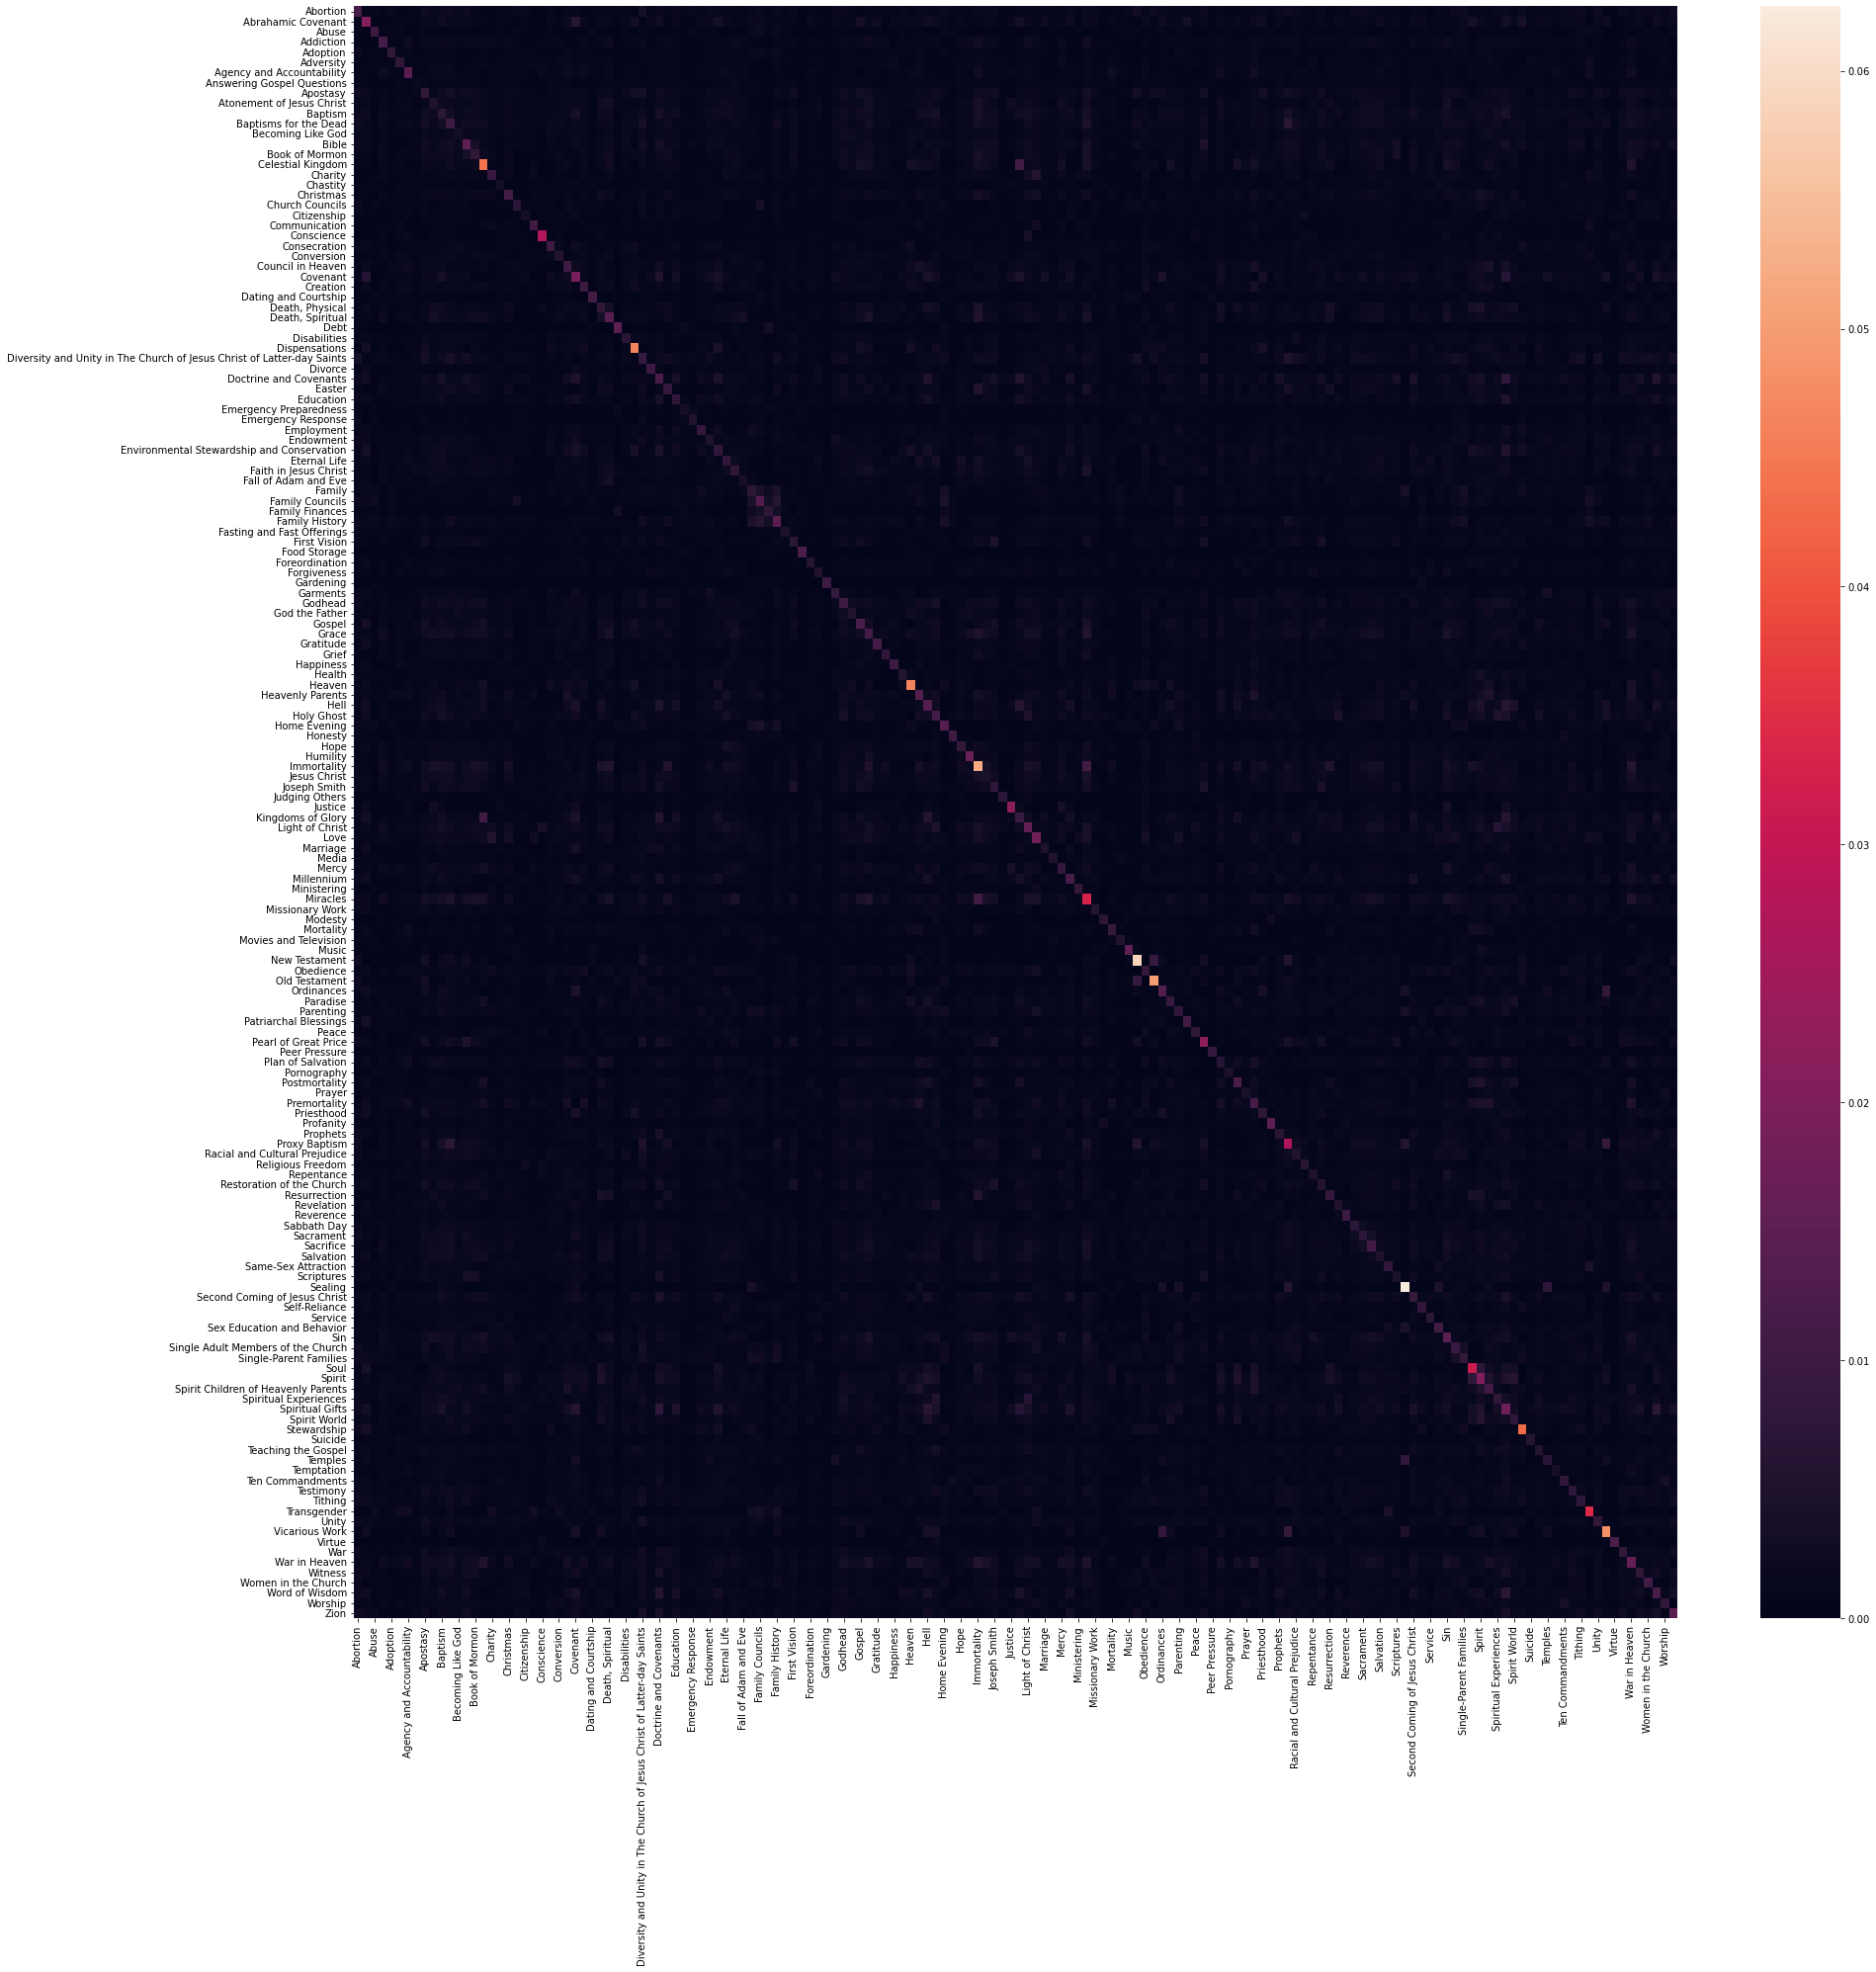

In [10]:
corr_matrix = np.matmul(dtm_labels_tf, dtm_labels_tf.transpose())
print(f"Shape of correlation matrix: {corr_matrix.shape}")

df_corr = pd.DataFrame(
    data=corr_matrix,
    index=topic_df['topic'].values,
    columns=topic_df['topic'].values
)

# Save correlation matrix
df_corr.to_csv('experiments/topic_correlations.csv')

# Display heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(df_corr)
plt.show()

Alternate correlation matrix, using normalized term counts rather than plain counts.

Shape of correlation matrix: (158, 158)


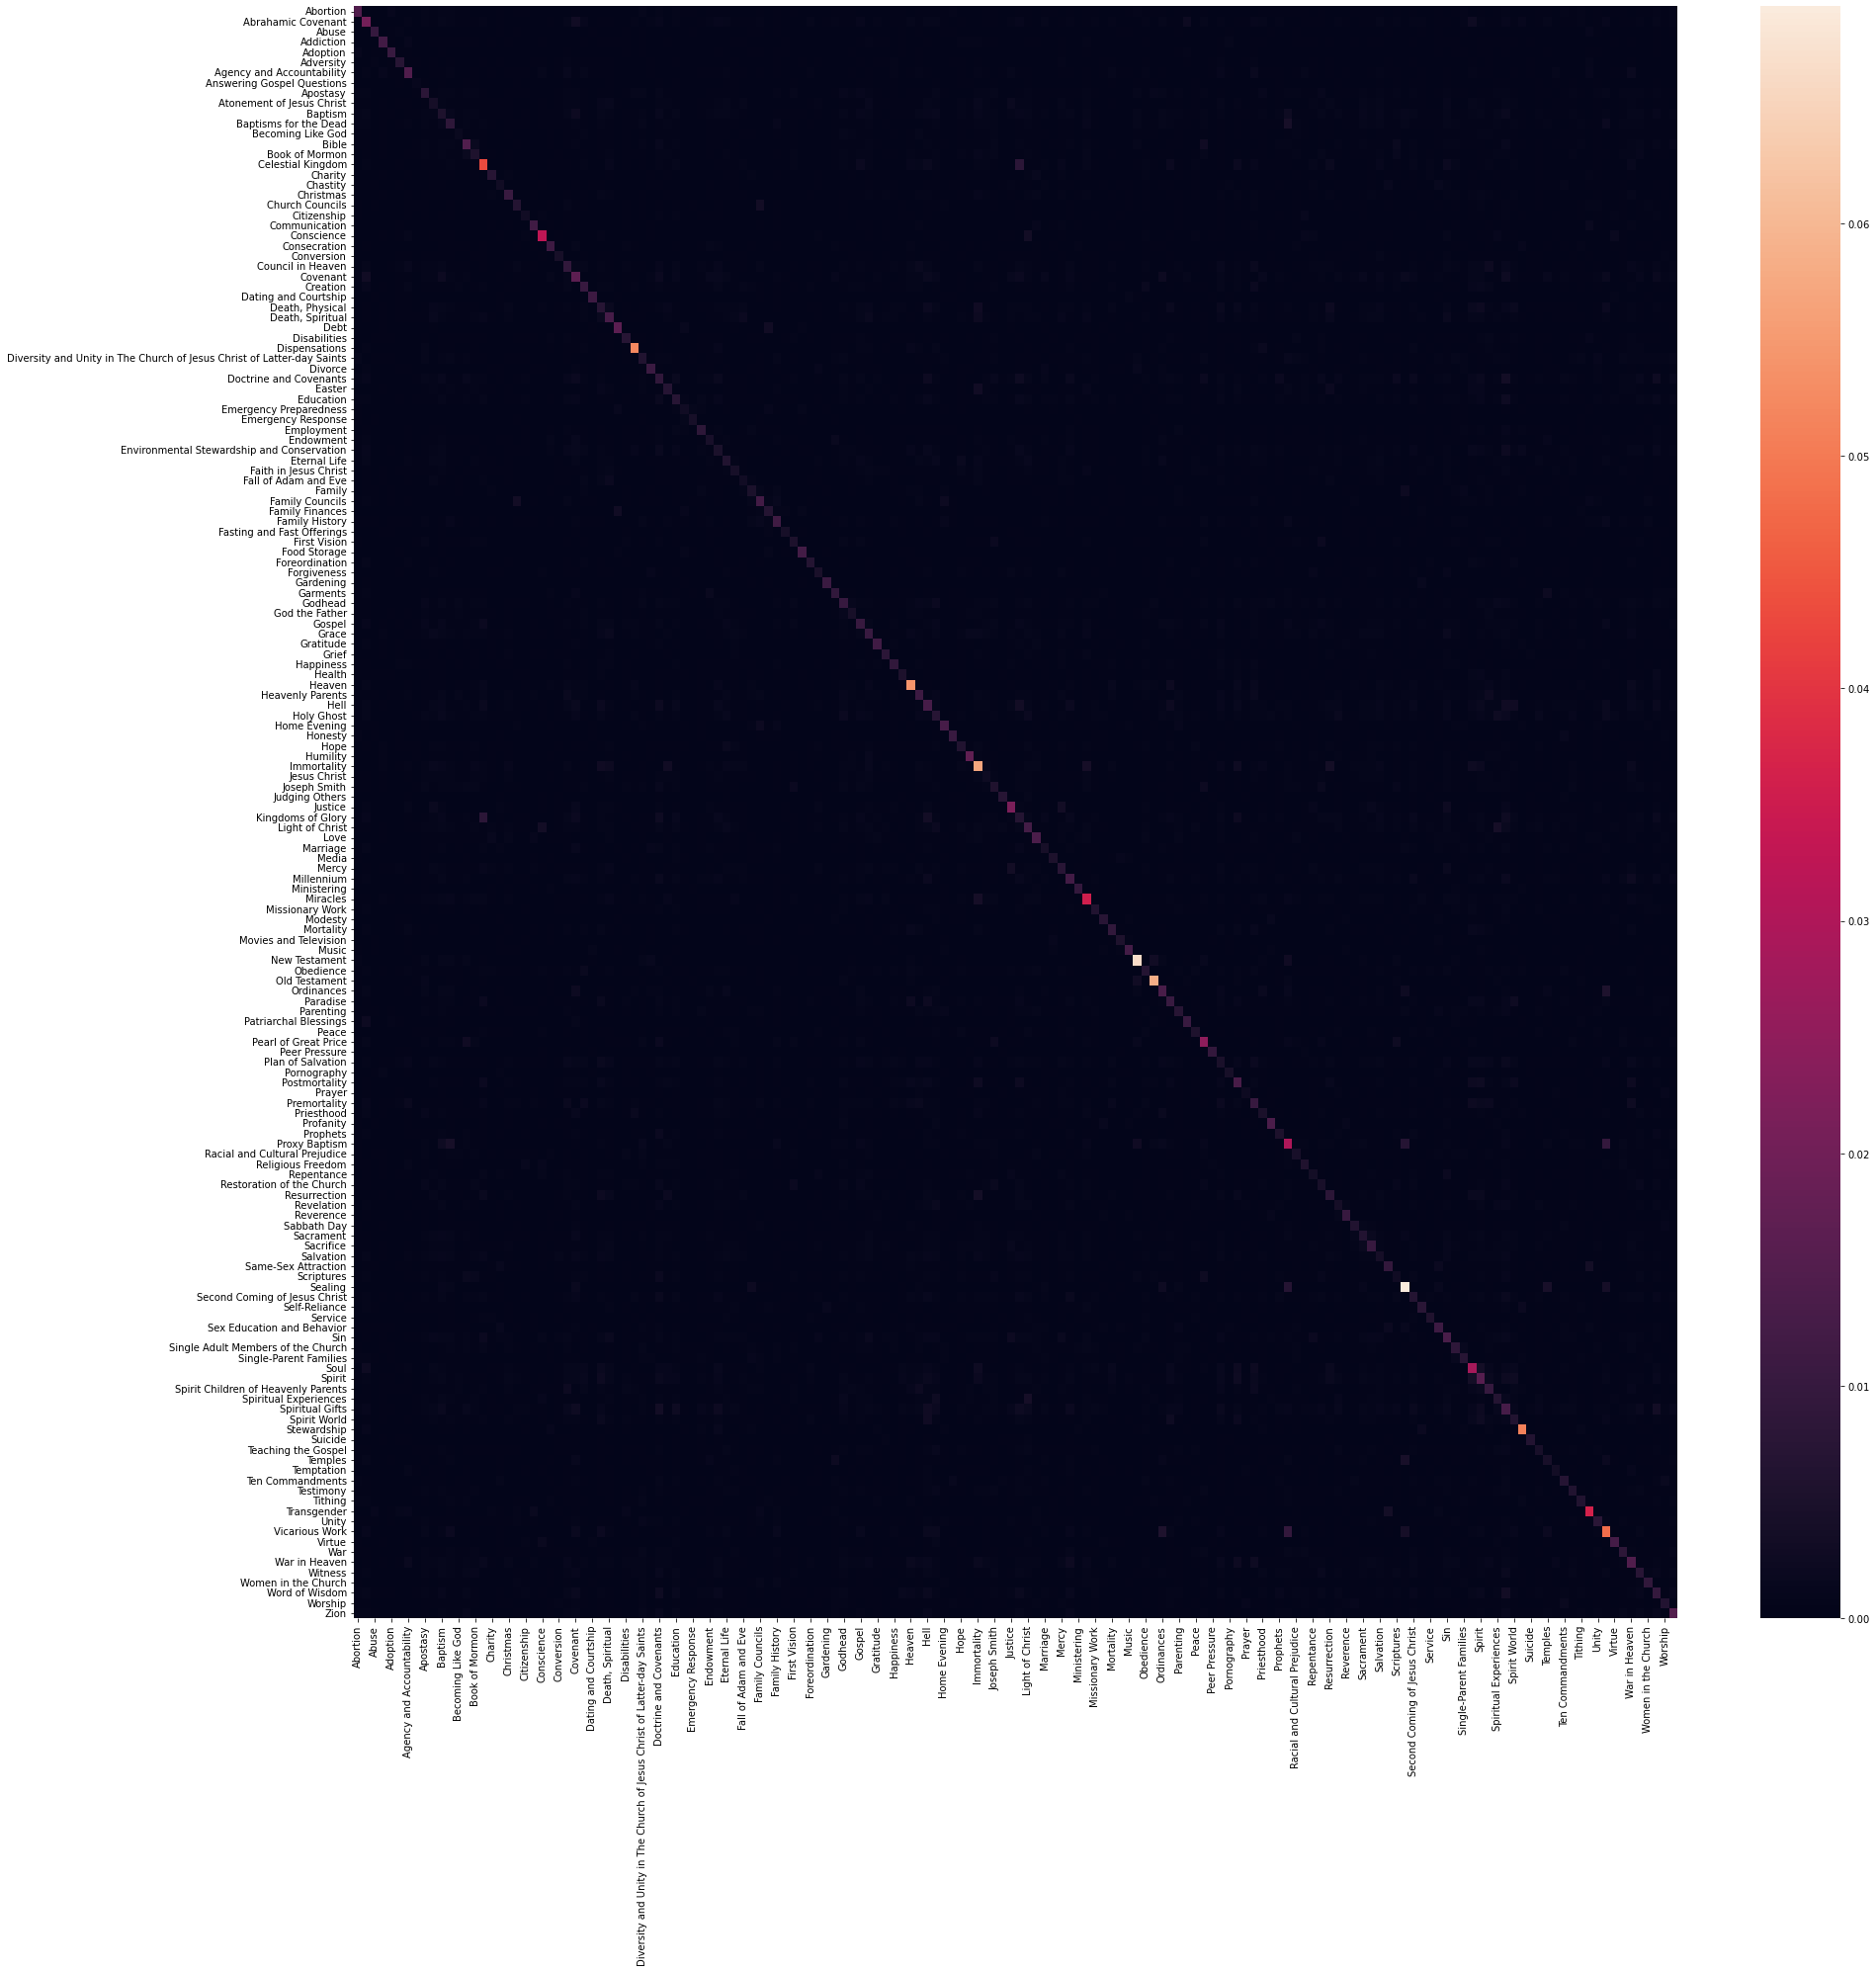

In [17]:
corr_matrix = np.matmul(dtm_labels_tfidf, dtm_labels_tfidf.transpose())
print(f"Shape of correlation matrix: {corr_matrix.shape}")

df_corr = pd.DataFrame(
    data=corr_matrix,
    index=topic_df['topic'].values,
    columns=topic_df['topic'].values
)

# Save correlation matrix
df_corr.to_csv('experiments/topic_correlations.csv')

# Display heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(30, 30))
sns.heatmap(df_corr)
plt.show()

### Find the documents that best represent each topic
This will help with understanding how effective the topic categorization was by showing the "quintessential" documents for each topic; that is, the documents whose terms (words, ngrams) are most similar to the topic.

I'll create matrices where each row is one topic, and the columns are the similarity scores across all documents.

> **Takeaway:** The topic categorization is generally very effective, with a few exceptions for common documents that appear across multiple topics.

In [263]:
naive_tf_top_docs_per_topic = np.matmul(
    dtm_labels_tf,
    dtm_tf[:-num_topics].toarray().transpose())

naive_tfidf_top_docs_per_topic = np.matmul(
    dtm_labels_tfidf,
    dtm_tfidf[:-num_topics].toarray().transpose())

print(f"Shape of topics-docs matrix for TF: {naive_tf_top_docs_per_topic.shape}")
print(f"Shape of topics-docs matrix for TF-IDF: {naive_tfidf_top_docs_per_topic.shape}")

Shape of topics-docs matrix for TF: (161, 1000)
Shape of topics-docs matrix for TF-IDF: (161, 1000)


In [266]:
top3docs_naive_tf = pd.DataFrame(
    data = naive_tf_top_docs_per_topic.argsort()[:, : -4 : -1],
    columns = ['tf_doc1', 'tf_doc2', 'tf_doc3'],
    index = topic_df.index
).apply(
    lambda s: pd.Series([sample_df['url'].values[i] for i in s],
        index = ['tf_doc1', 'tf_doc2', 'tf_doc3']),
    axis = 1)

top3docs_naive_tfidf = pd.DataFrame(
    data = naive_tfidf_top_docs_per_topic.argsort()[:, : -4 : -1],
    columns = ['tfidf_doc1', 'tfidf_doc2', 'tfidf_doc3'],
    index = topic_df.index
).apply(
    lambda s: pd.Series([sample_df['url'].values[i] for i in s],
        index = ['tfidf_doc1', 'tfidf_doc2', 'tfidf_doc3']),
    axis = 1)

# Combine into a single DataFrame
topic_df_full = topic_df.join(
    [
        top3docs_naive_tf,
        top3docs_naive_tfidf
    ]
)

topic_df_full.to_csv('experiments/topics_naive_models.csv', index=False)

topic_df_full.head()

,url,topic,text,tf_doc1,tf_doc2,tf_doc3,tfidf_doc1,tfidf_doc2,tfidf_doc3
0,https://www.churchofjesuschrist.org/study/manu...,Abortion,Abortion: See the Church’s official statement ...,https://www.churchofjesuschrist.org/study/new-...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...
1,https://www.churchofjesuschrist.org/study/manu...,Abrahamic Covenant,Abrahamic Covenant: Abraham made covenants wit...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...
2,https://www.churchofjesuschrist.org/study/manu...,Abuse,Abuse: Abuse is the mistreatment or neglect of...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/new-...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/liah...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/ensi...
3,https://www.churchofjesuschrist.org/study/manu...,Addiction,Addiction: Addiction is a persistent dependenc...,https://www.churchofjesuschrist.org/study/liah...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/new-...,https://www.churchofjesuschrist.org/study/new-...,https://www.churchofjesuschrist.org/study/liah...,https://www.churchofjesuschrist.org/study/new-...
4,https://www.churchofjesuschrist.org/study/manu...,Adoption,Adoption: The scriptures teach us that God lov...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/liah...,https://www.churchofjesuschrist.org/study/new-...,https://www.churchofjesuschrist.org/study/ensi...,https://www.churchofjesuschrist.org/study/frie...,https://www.churchofjesuschrist.org/study/ensi...


### Assign topic labels to documents

For matrix multiplication, $(m\_rows, n\_cols) x (n\_rows, p\_cols)$ -> $(m\_rows, p\_cols)$

In [258]:
naive_topic_guesses_tf = np.matmul(
    dtm_tf[:-num_topics].toarray(), 
    dtm_labels_tf.transpose())

naive_topic_guesses_tfidf = np.matmul(
    dtm_tfidf[:-num_topics].toarray(), 
    dtm_labels_tfidf.transpose())

In [259]:
print(f"Topic distribution (naive method), TF: {naive_topic_guesses_tf.shape}")
print(f"Topic distribution (naive method), TF-IDF: {naive_topic_guesses_tfidf.shape}")

Topic distribution (naive method), TF: (1000, 161)
Topic distribution (naive method), TF-IDF: (1000, 161)


In [260]:
# Create DataFrames with the names of the top 3 categories 
# based on the naive implementation.
# First grab indices (array.argsort(), all rows and last three cols), 
# then translate to category names with df.apply().
top3_naive_tf = pd.DataFrame(
    data = naive_topic_guesses_tf.argsort()[:, : -4 : -1],
    columns = ['naive_tf1', 'naive_tf2', 'naive_tf3'],
    index = sample_df.index
).apply(
    lambda s: pd.Series([topic_df.at[i, "topic"] for i in s.values],
        index = ['naive_tf1', 'naive_tf2', 'naive_tf3']),
    axis = 1)

top3_naive_tfidf = pd.DataFrame(
    data = naive_topic_guesses_tfidf.argsort()[:, : -4 : -1],
    columns = ['naive_tfidf1', 'naive_tfidf2', 'naive_tfidf3'],
    index = sample_df.index
).apply(
    lambda s: pd.Series([topic_df.at[i, "topic"] for i in s.values], 
        index = ['naive_tfidf1', 'naive_tfidf2', 'naive_tfidf3']),
    axis = 1)

# Create DataFrames with the scores of the top 3 categories
# based on the naive implementation (both Term Frequency and TF-IDF)
temp_scores = naive_topic_guesses_tf.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3_scores_naive_tf = pd.DataFrame(
    data = temp_scores,
    columns = ['naive_tf_score1', 'naive_tf_score2', 'naive_tf_score3'],
    index = sample_df.index)

temp_scores = naive_topic_guesses_tfidf.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3_scores_naive_tfidf = pd.DataFrame(
    data = temp_scores,
    columns = ['naive_tfidf_score1', 'naive_tfidf_score2', 'naive_tfidf_score3'],
    index = sample_df.index)

In [261]:
# Merge into the sample_df DataFrame
sample_df_full = sample_df.join(
    [
        top3_naive_tf,
        top3_scores_naive_tf,
        top3_naive_tfidf,
        top3_scores_naive_tfidf
    ]
)

# Display the DataFrame
sample_df_full.head()

,url,text,naive_tf1,naive_tf2,naive_tf3,naive_tf_score1,naive_tf_score2,naive_tf_score3,naive_tfidf1,naive_tfidf2,naive_tfidf3,naive_tfidf_score1,naive_tfidf_score2,naive_tfidf_score3
57430,https://www.churchofjesuschrist.org/study/frie...,Our mom made temple cards from the temple pict...,Sealing,Temples,Garments,0.438,0.434,0.231,Temples,Sealing,Garments,0.010,0.009,0.006
1971,https://www.churchofjesuschrist.org/study/liah...,"In “The Family: A Proclamation to the World,” ...",Single-Parent Families,Family History,Family,0.247,0.199,0.196,Single-Parent Families,Transgender,Marriage,0.018,0.012,0.012
8299,https://www.churchofjesuschrist.org/study/liah...,"Saturday Morning, October 4, 2008, General Ses...",Music,Virtue,Addiction,0.929,0.702,0.664,Music,Virtue,Christmas,0.009,0.008,0.005
63503,https://www.churchofjesuschrist.org/study/frie...,"To find the names of colors you know,\nChange ...",Heaven,Articles of Faith,Profanity,0.040,0.036,0.032,Profanity,Articles of Faith,Heaven,0.004,0.004,0.004
12976,https://www.churchofjesuschrist.org/study/liah...,"To make this marble game, you will need: a car...",New Testament,Profanity,Hell,0.118,0.056,0.054,New Testament,Celestial Kingdom,Hell,0.003,0.001,0.001


## `sklearn` methods: LDA and NMF

**Takeaway:** Use NMF. MiniBatchNMF might work well for a larger set of documents, but NMF did fantastic (highly accurate categories) and completed in less time than MiniBatchNMF. LDA's topics were much less cohesive compared to NMF, but it is much faster than NMF (roughly 1/3 to 1/4 the time). The extra time for NMF is worth it.

Other things:
- For both NMF models, I used TF-IDF doc-terms matrix, since that normalizes to control for common words across all documents. In addition to stopwords, this helps bring focus to more meaningful terms.
- I set ngram_range to (1, 2) to include single words and bigrams.
- I tested setting the `max_features` parameter on the `TfidfVectorizer` to speed up processing time for NMF by limiting the number of terms in the doc-terms matrix. I set it to 5,000 to limit the terms matrix to the top-5,000 terms based on term frequency, so only those terms were used for assigning categories. This version performed much worse than the `NMF` with all features, but it was way faster (coverged at 260 iterations in about 2.5 minutes).
- I removed all words that occured in only 1 document as well as words that occured in over 95% of documents.
- Setting `verbose=1` on either NMF model will print the model's loss each iteration. Can be helpful to notice its improvement over time.
- I used the default settings for NMF except I set `init='nndsvda'`, which is the initialization strategy used for MiniBatchNMF, and is the setting that Scikit-Learn used in the example code comparing NMF to MiniBatchNMF and LDA.
- NMF said it reached the full 200 iterations without converging, so I could try increasing max_iter for a better result. As it is, it did fantastically well.
- I fit the models with the topics' doc-term matrix included, which probably helped the models assign categories since they had access to the full array of words, compared to if I had filtered to include only the documents from the doc-terms matrix but not the topics.
- Using my matrix-multiplication method, some topics were combined under a single label (i.e., 161 topics condensed to 98 for NMF, 92 for MiniBatch NMF, and 86 for LDA), but the word distribution shows that those topics fit well together.

### Set up models

In [102]:
lda = LatentDirichletAllocation(
    n_components = num_topics,
    n_jobs = -1,                    # set to -1 to use all available processors
    # learning_method = 'online',   # set to 'online' for batch processing to increase speed when used on large datasets
    # max_iter = 20,                # default is 10
    random_state = 0
)

nmf = NMF(
    n_components = num_topics,
    random_state = 0,
    init = 'nndsvda',
    verbose = 1,    # show loss progress each iteration
    max_iter = 1000,
    # beta_loss = 'frobenius',
    # alpha_W = 0.00005,
    # alpha_H = 0.00005,
    # l1_ratio = 1
)

mini_nmf = MiniBatchNMF(
    n_components = num_topics,
    random_state = 0,
    # verbose = 1, 
    # init = 'nndsvda',
    # beta_loss = 'frobenius',
    # alpha_W = 0.00005,
    # alpha_H = 0.00005,
    # l1_ratio = 1
)

# Create NMF model for 5,000-term doc-terms matrix
nmf_5k = NMF(
    n_components = num_topics,
    random_state = 0,
    init = 'nndsvda',
    max_iter = 1000,
    verbose = 1    # show loss progress each iteration
)

# Create topic-term matrix (ttm) for term-frequency (CountVectorizer)
# and term-frequency inverse-document-frequency (TfidfVectorizer)

# Include topics when fitting the models
print("Fitting the LDA model on TF doc-terms matrix...")
t0 = time.perf_counter()
lda.fit(dtm_tf)
print(f"✅ Completed in {time.perf_counter() - t0:,.2f} seconds")

print("\nFitting the NMF model on TF-IDF doc-terms matrix...")
t0 = time.perf_counter()
nmf.fit(dtm_tfidf)
print(f"✅ Completed in {time.perf_counter() - t0:,.2f} seconds.")

print("\nFitting the MiniBatch NMF model on TF-IDF doc-terms matrix...")
t0 = time.perf_counter()
mini_nmf.fit(dtm_tfidf)
print(f"✅ Completed in {time.perf_counter() - t0:,.2f} seconds.")

print("\nFitting the NMF_5k model on TF-IDF doc-terms matrix (of top 5,000 terms)...")
t0 = time.perf_counter()
nmf_5k.fit(dtm_tfidf_5k)
print(f"✅ Completed in {time.perf_counter() - t0:,.2f} seconds.")

# Alternatively, exclude the topics when fitting the models.
# May be sub-optimal since the topics contain some of the 
# important key words that might help the models assign categories.
# lda.fit(dtm_tf[:-num_topics])
# nmf.fit(dtm_tfidf[:-num_topics])
# mini_nmf.fit(dtm_tfidf[:-num_topics])

Fitting the LDA model on TF doc-terms matrix...
✅ Completed in 103.404 seconds
Fitting the NMF model on TF-IDF doc-terms matrix...
violation: 1.0
violation: 0.18634736790086245
violation: 0.1435414294237958
violation: 0.10501192521280682
violation: 0.08377926663957845
violation: 0.07091346003315079
violation: 0.062210874989608145
violation: 0.05547379203614301
violation: 0.04996488316584742
violation: 0.044720198184328847
violation: 0.040282606780879956
violation: 0.03626953143636662
violation: 0.03312032165135409
violation: 0.029977764868467528
violation: 0.027193281049658062
violation: 0.0246142453646808
violation: 0.022565587027887964
violation: 0.02097761956479925
violation: 0.01959378777585296
violation: 0.018350240424185704
violation: 0.01743194363095484
violation: 0.016378690027955306
violation: 0.015342037453243494
violation: 0.014333089766854615
violation: 0.013413950197542789
violation: 0.012741534228390456
violation: 0.01232224168125108
violation: 0.01195925101315002
violati

c:\Users\Ryan\anaconda3\envs\stapps\lib\site-packages\sklearn\decomposition\_nmf.py:1692: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


✅ Completed in 711.539 seconds.
Fitting the MiniBatch NMF model on TF-IDF doc-terms matrix...


c:\Users\Ryan\anaconda3\envs\stapps\lib\site-packages\sklearn\decomposition\_nmf.py:2308: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


✅ Completed in 846.565 seconds.


### Assign labels to computed topics

For matrix multiplication, $(m\_rows, n\_cols) x (n\_rows, p\_cols)$ -> $(m\_rows, p\_cols)$

So, the following code uses a transposed version of the doc-terms matrix for the topics so that the columns and row dimensions align properly. Here's an example:

```python
lda.components_.shape
# -> (2, 57)
dtm_labels.transpose().shape
# -> (57, 2)
# Perform matrix multiplcation of ...
# lda_topic_guesses = lda.components_ x dtm_labels.transpose()
lda_topic_guesses.shape
# -> (2, 2)
```

In [248]:
lda_topic_guesses = np.matmul(
    lda.components_, 
    dtm_labels_tf.transpose())

nmf_topic_guesses = np.matmul(
    nmf.components_, 
    dtm_labels_tfidf.transpose())

mini_nmf_topic_guesses = np.matmul(
    mini_nmf.components_, 
    dtm_labels_tfidf.transpose())

nmf_5k_topic_guesses = np.matmul(
    nmf_5k.components_, 
    dtm_labels_tfidf_5k.transpose())

Check the shape of the topic-terms matrix -- it should be `num_topics` rows x `num_topics` columns, where each row is a topic computed by LDA and each column is the score of that topic compared to the labeled topics.

The argmax (index of the highest score) should correspond with the most likely topic for the topic computed by the LDA algorith.

In [250]:
lda_topic_guesses.shape

(161, 161)

In [251]:
print(f"LDA topics condensed to: {len(set(lda_topic_guesses.argmax(axis=1)))}")
print(f"NMF topics condensed to: {len(set(nmf_topic_guesses.argmax(axis=1)))}")
print(f"MiniBatch NMF topics condensed to: {len(set(mini_nmf_topic_guesses.argmax(axis=1)))}")
print(f"NMF_5k topics condensed to: {len(set(nmf_5k_topic_guesses.argmax(axis=1)))}")

LDA topics condensed to: 86
NMF topics condensed to: 98
MiniBatch NMF topics condensed to: 92
NMF_5k topics condensed to: 94


In [252]:
lda_topic_names = [topic_df.at[idx, 'topic'] for idx in lda_topic_guesses.argmax(axis=1)]
nmf_topic_names = [topic_df.at[idx, 'topic'] for idx in nmf_topic_guesses.argmax(axis=1)]
mini_nmf_topic_names = [topic_df.at[idx, 'topic'] for idx in mini_nmf_topic_guesses.argmax(axis=1)]
nmf_5k_topic_names = [topic_df.at[idx, 'topic'] for idx in nmf_5k_topic_guesses.argmax(axis=1)]

In [111]:
# View assigned labels for the computed topics.
# We hope to see a good amount of variety here.
lda_topic_guesses.argmax(axis=1)

array([101,  88, 143,  49, 111,  15,  88,  68,  88, 128,  51,  59,  15,
       134,   9,  51,  97,  97,  52,  86,   9, 128,  71, 129,  77, 121,
        51,   2, 160, 148,  82,  41,  97,  90, 157, 119,  71,   9,  81,
        94,  97,   9,  20,  16, 159, 141,   1, 100,  70, 145, 128, 117,
        49,  56, 138,  44,   9, 157,  73,  77,  73,   9,  12,  81,  52,
       137,   9, 111,   9, 102,  82, 137,  35,  42,   5, 110, 160, 131,
        55, 149,  71,  19,  82, 155,  29,  82,  51,  83, 111,  49, 114,
       135, 156,  71,  82,  51, 111,  81, 128,  14, 140,  51,  89,  29,
        29,  58,  59, 116, 106,  96,  39,  63, 155,  54, 112,  87, 124,
        77,  64, 157,  84,  49, 111,  82,   4,  94,  75,  92,  54,   6,
        61, 123,  97, 131,  12,  53,   9,  82,  49,  97,  35, 109,  94,
        95,  30, 138,  82,  77, 157, 111,  34,  73,  51, 157,  75,  71,
       148,  67,  97,  82,  95], dtype=int64)

View information on a topic by index number.

In [112]:
topic_df.iloc[101]

Unnamed: 0                                                  135
url           https://www.churchofjesuschrist.org/study/manu...
topic                                     Patriarchal Blessings
text          Patriarchal Blessings: Every worthy, baptized ...
Name: 101, dtype: object

#### View the top $k$ labels for each topic (by index number)

Plotting technique adapted from the Scikit-Learn example: [Topic extraction with Non-negative Matrix Factorization and Latent Dirichlet Allocation](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html)

In [113]:
label_idxs = lda_topic_guesses[0].argsort()[: -4 : -1]
topic_names = [topic_df.at[i, "topic"] for i in label_idxs]
topic_scores = np.round(lda_topic_guesses[0][label_idxs], 2)
title_text = (f"Topic {0 +1}\n"
             + "\n".join([str(i) for i in zip(topic_names, topic_scores)]))
print(title_text)

Topic 1
('Patriarchal Blessings', 6.13)
('Priesthood Blessing', 2.82)
('Abrahamic Covenant', 2.12)


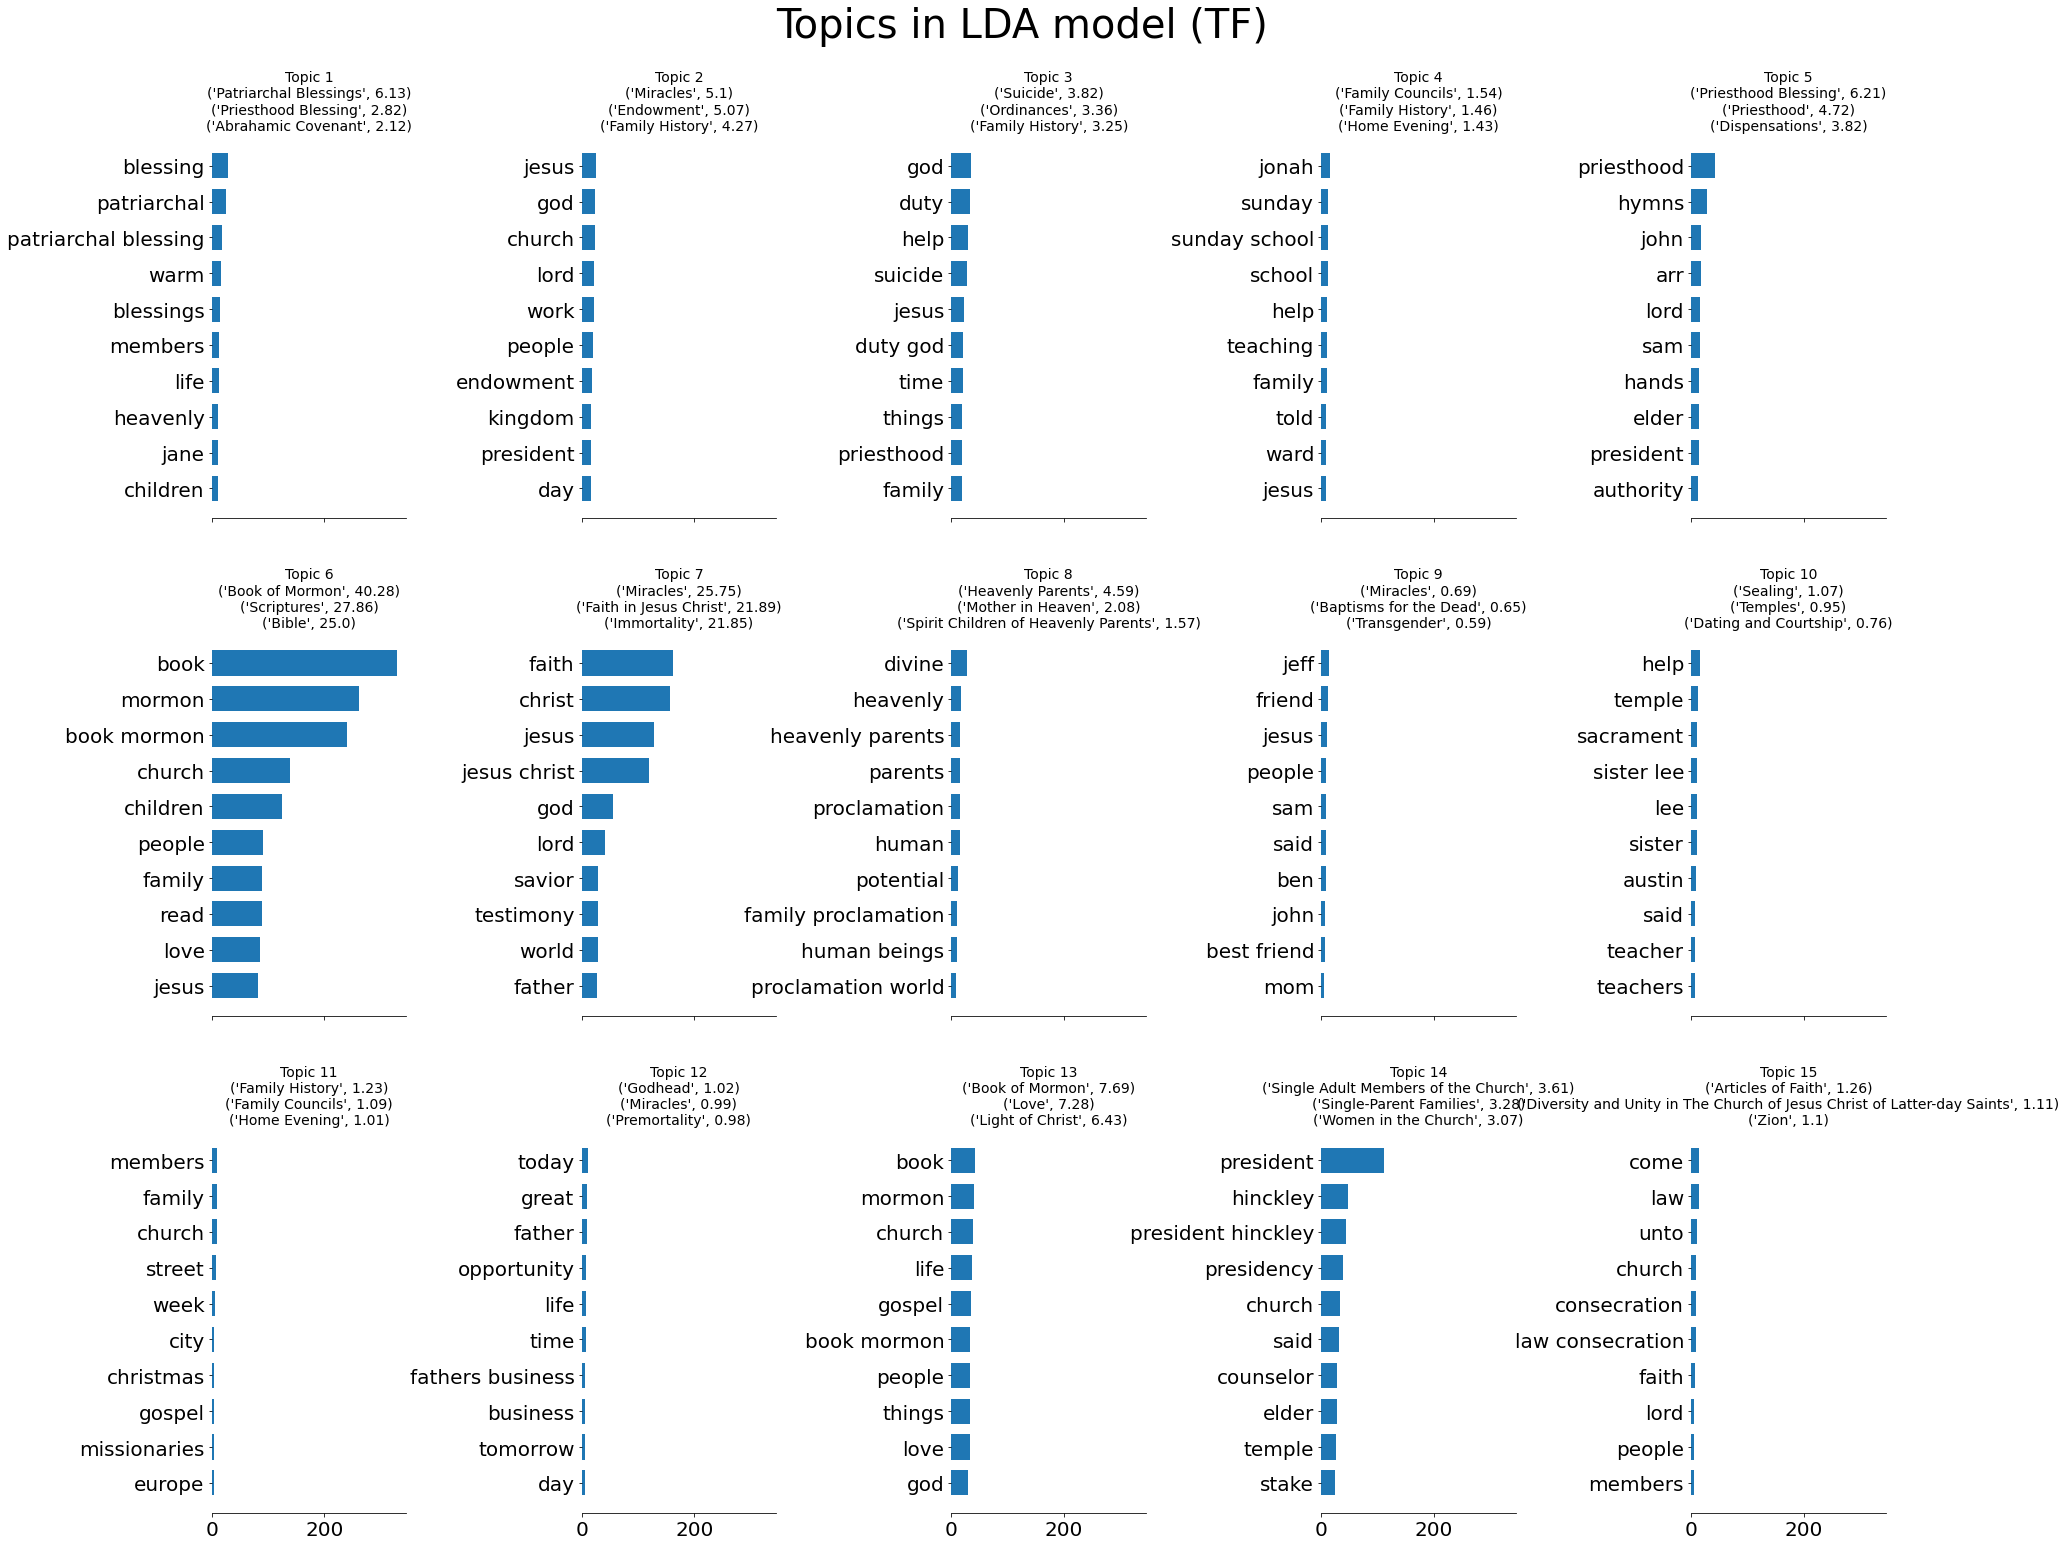

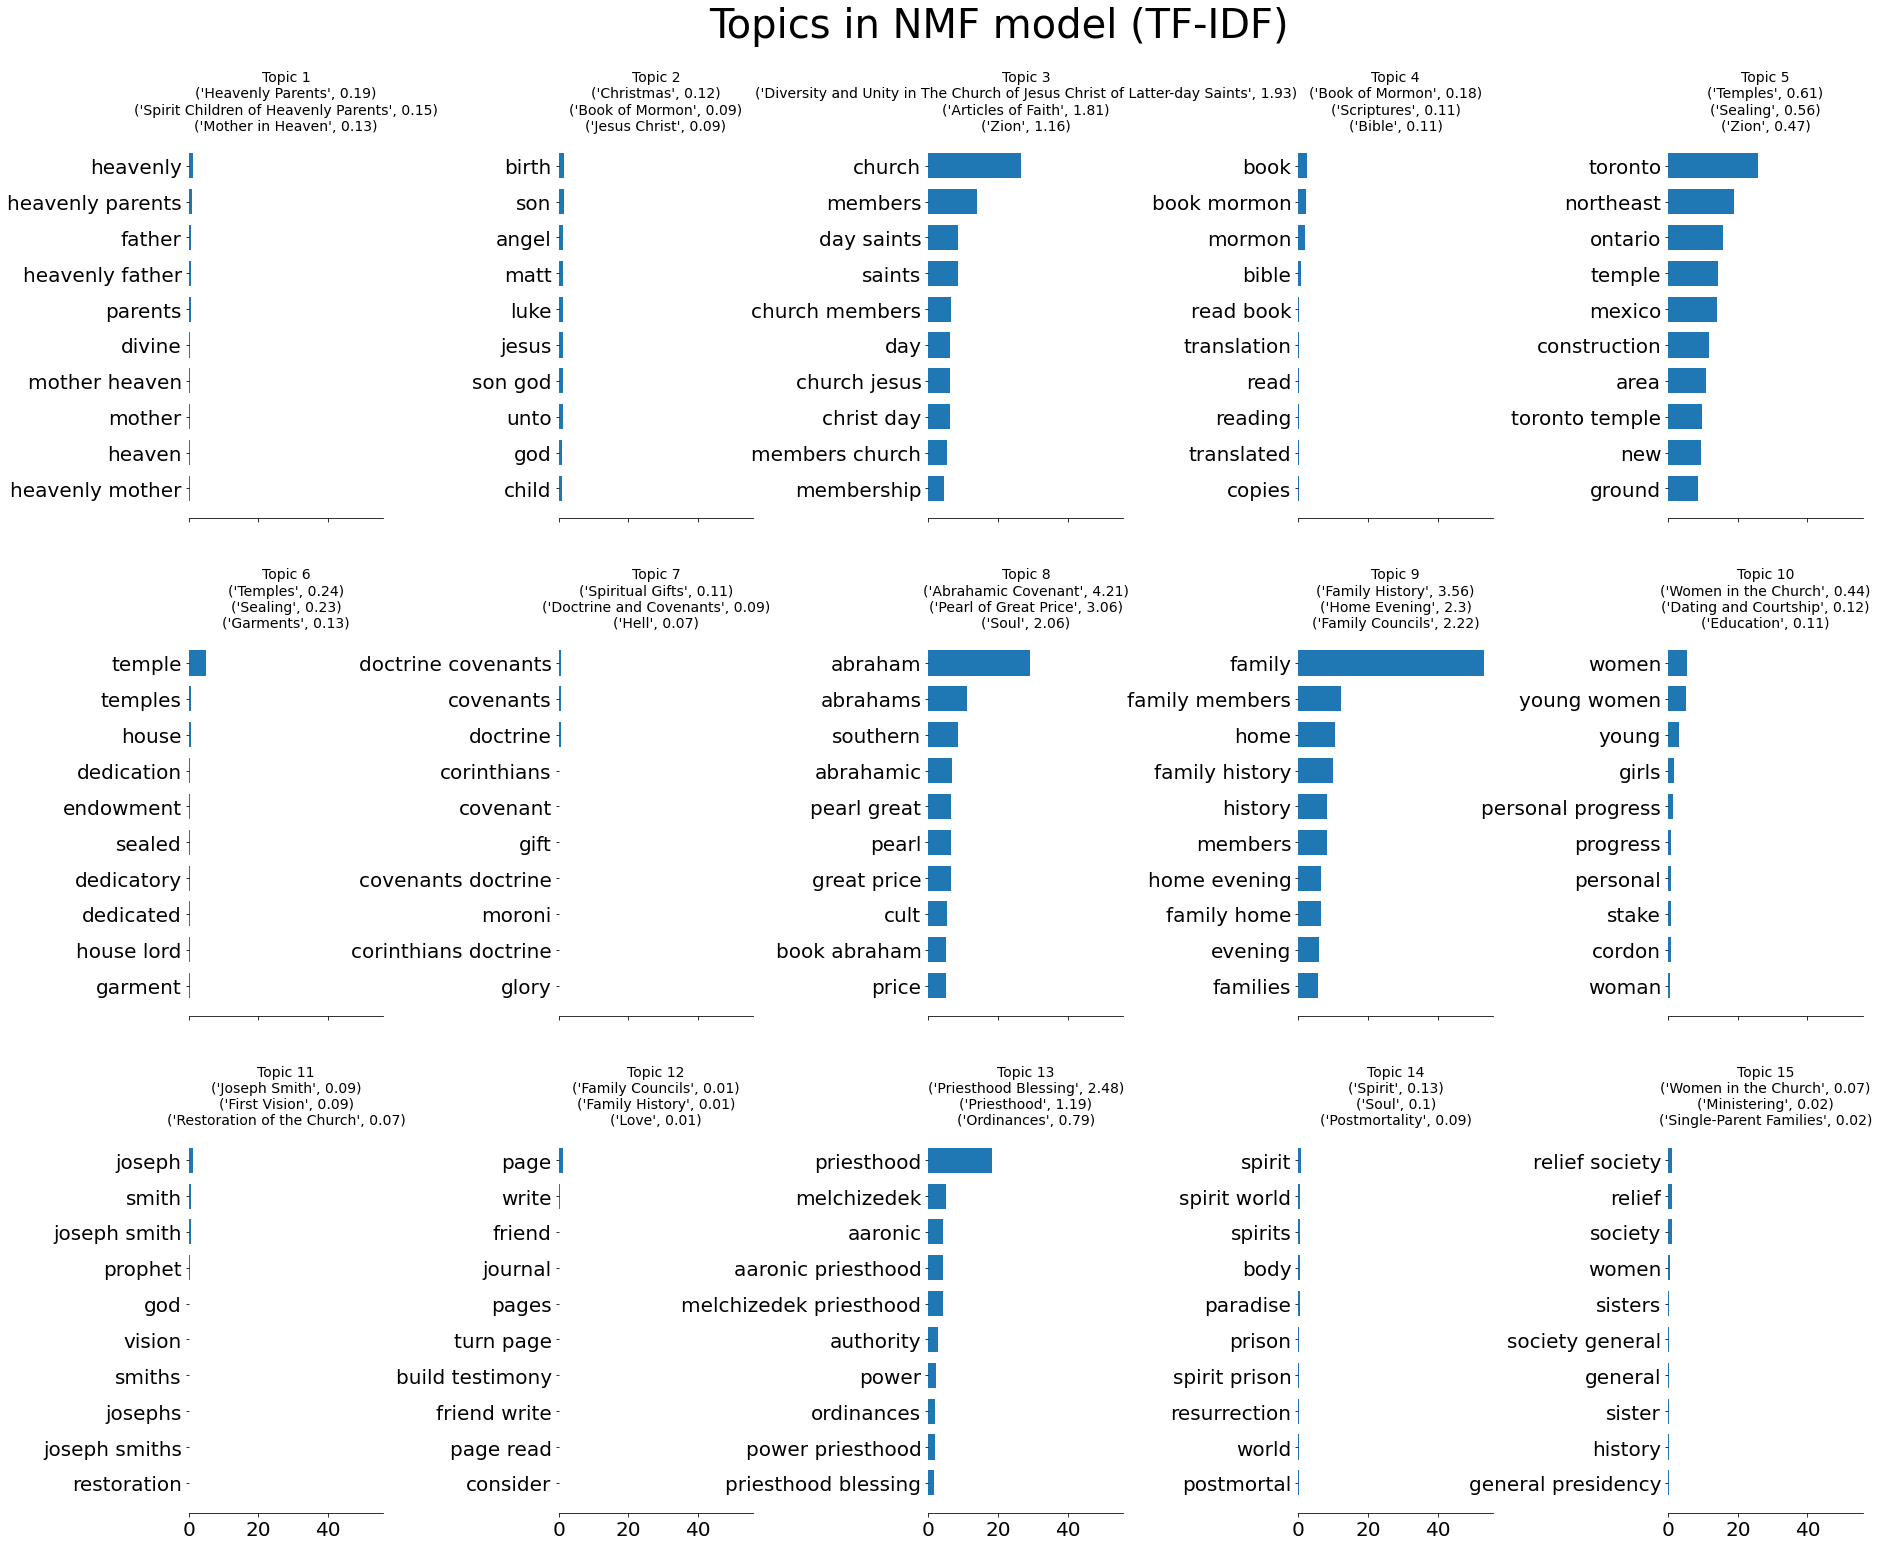

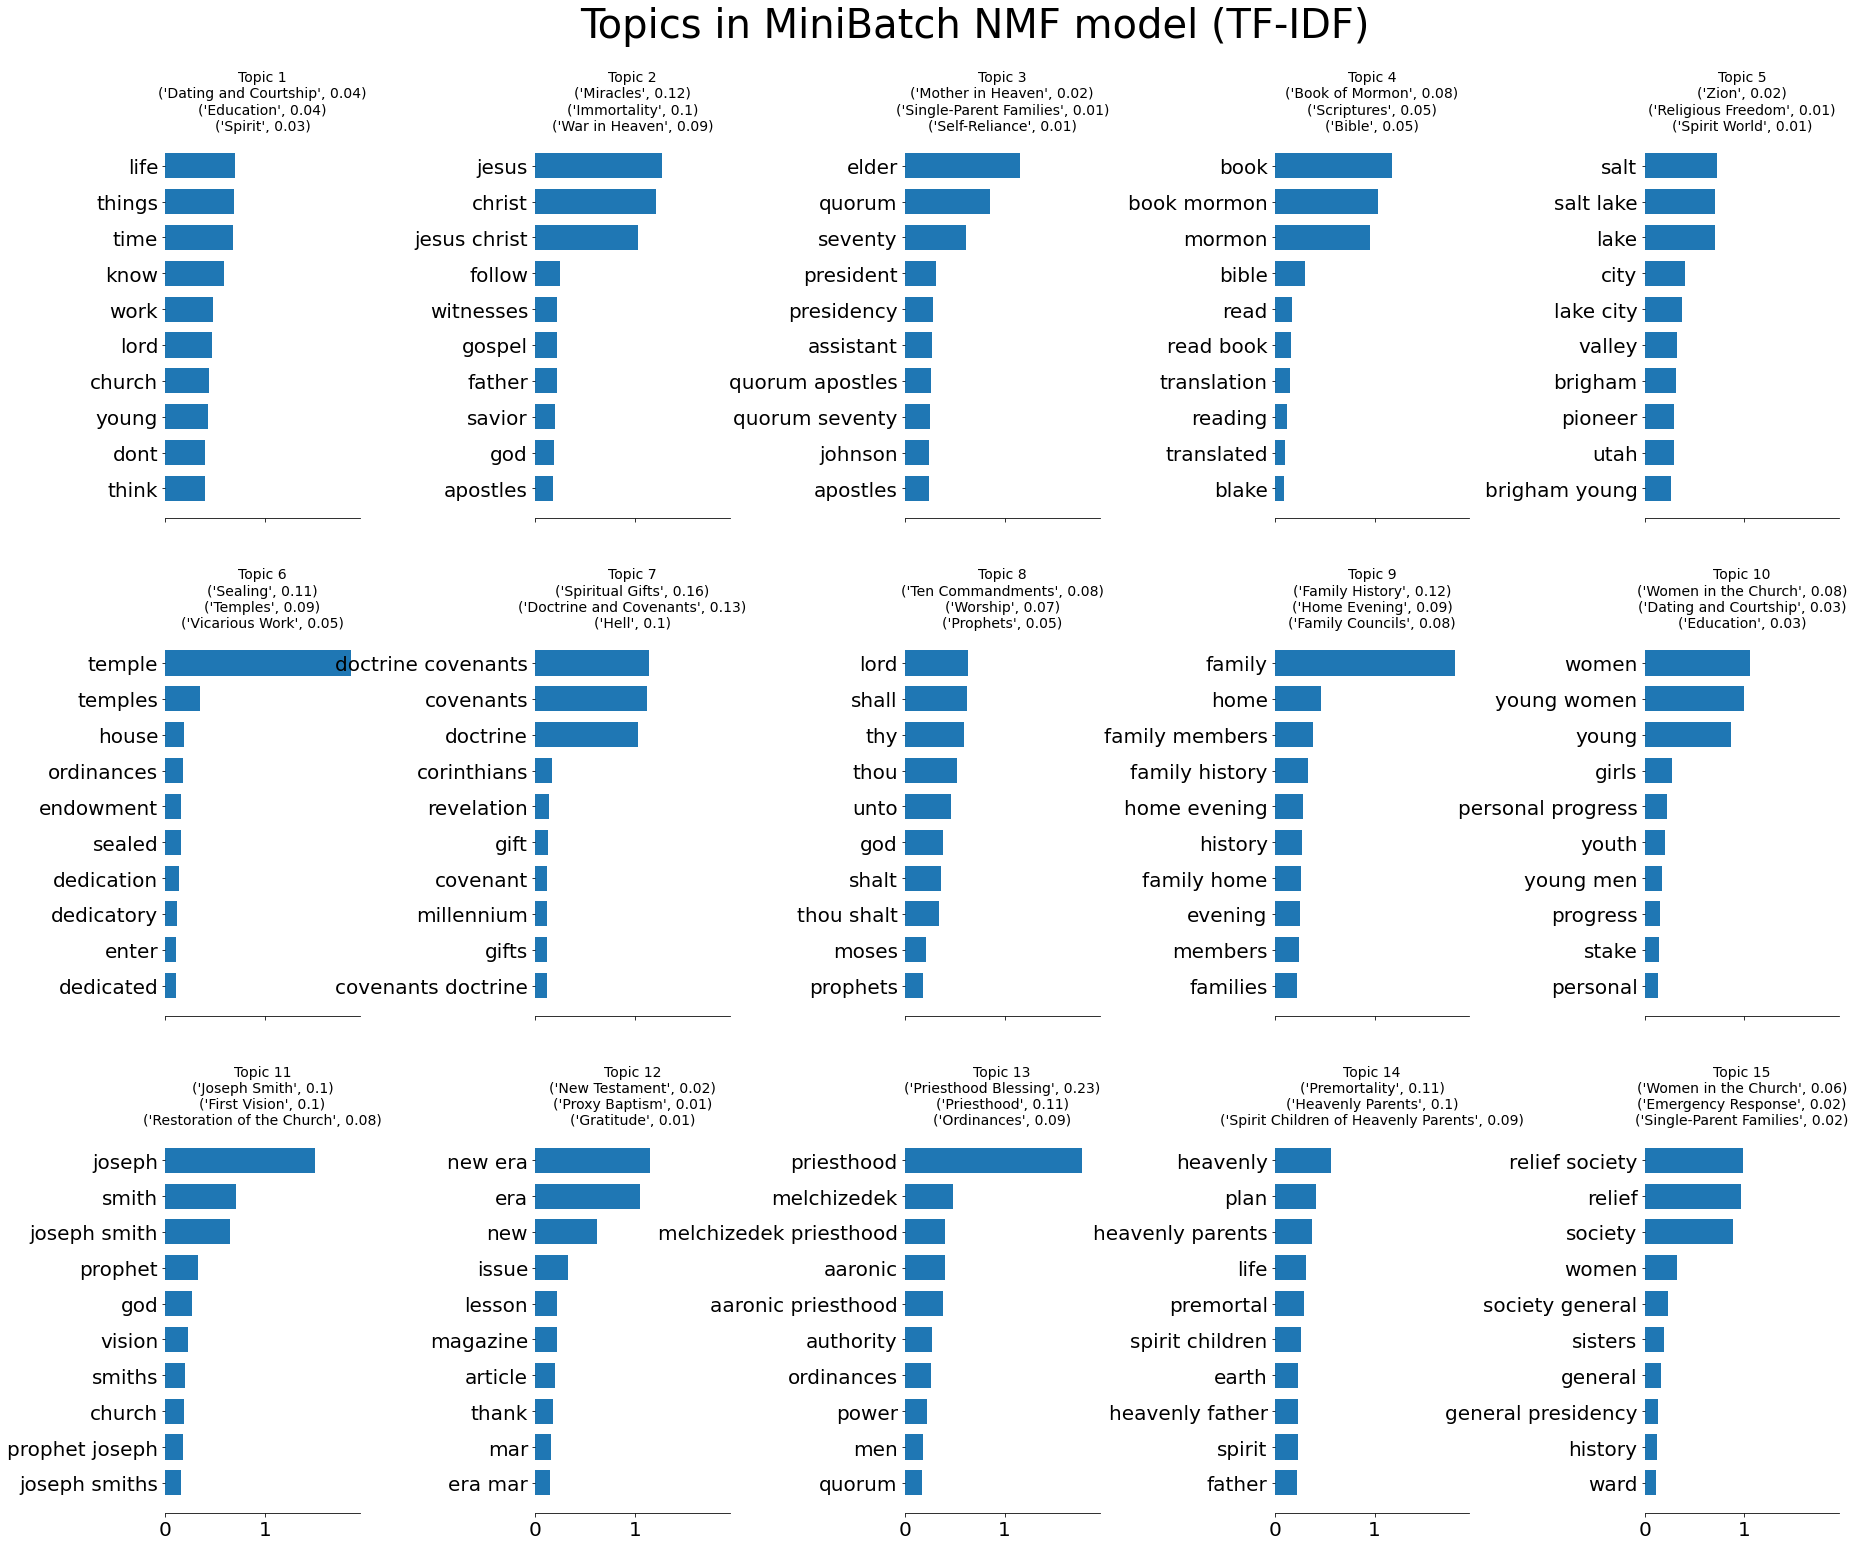

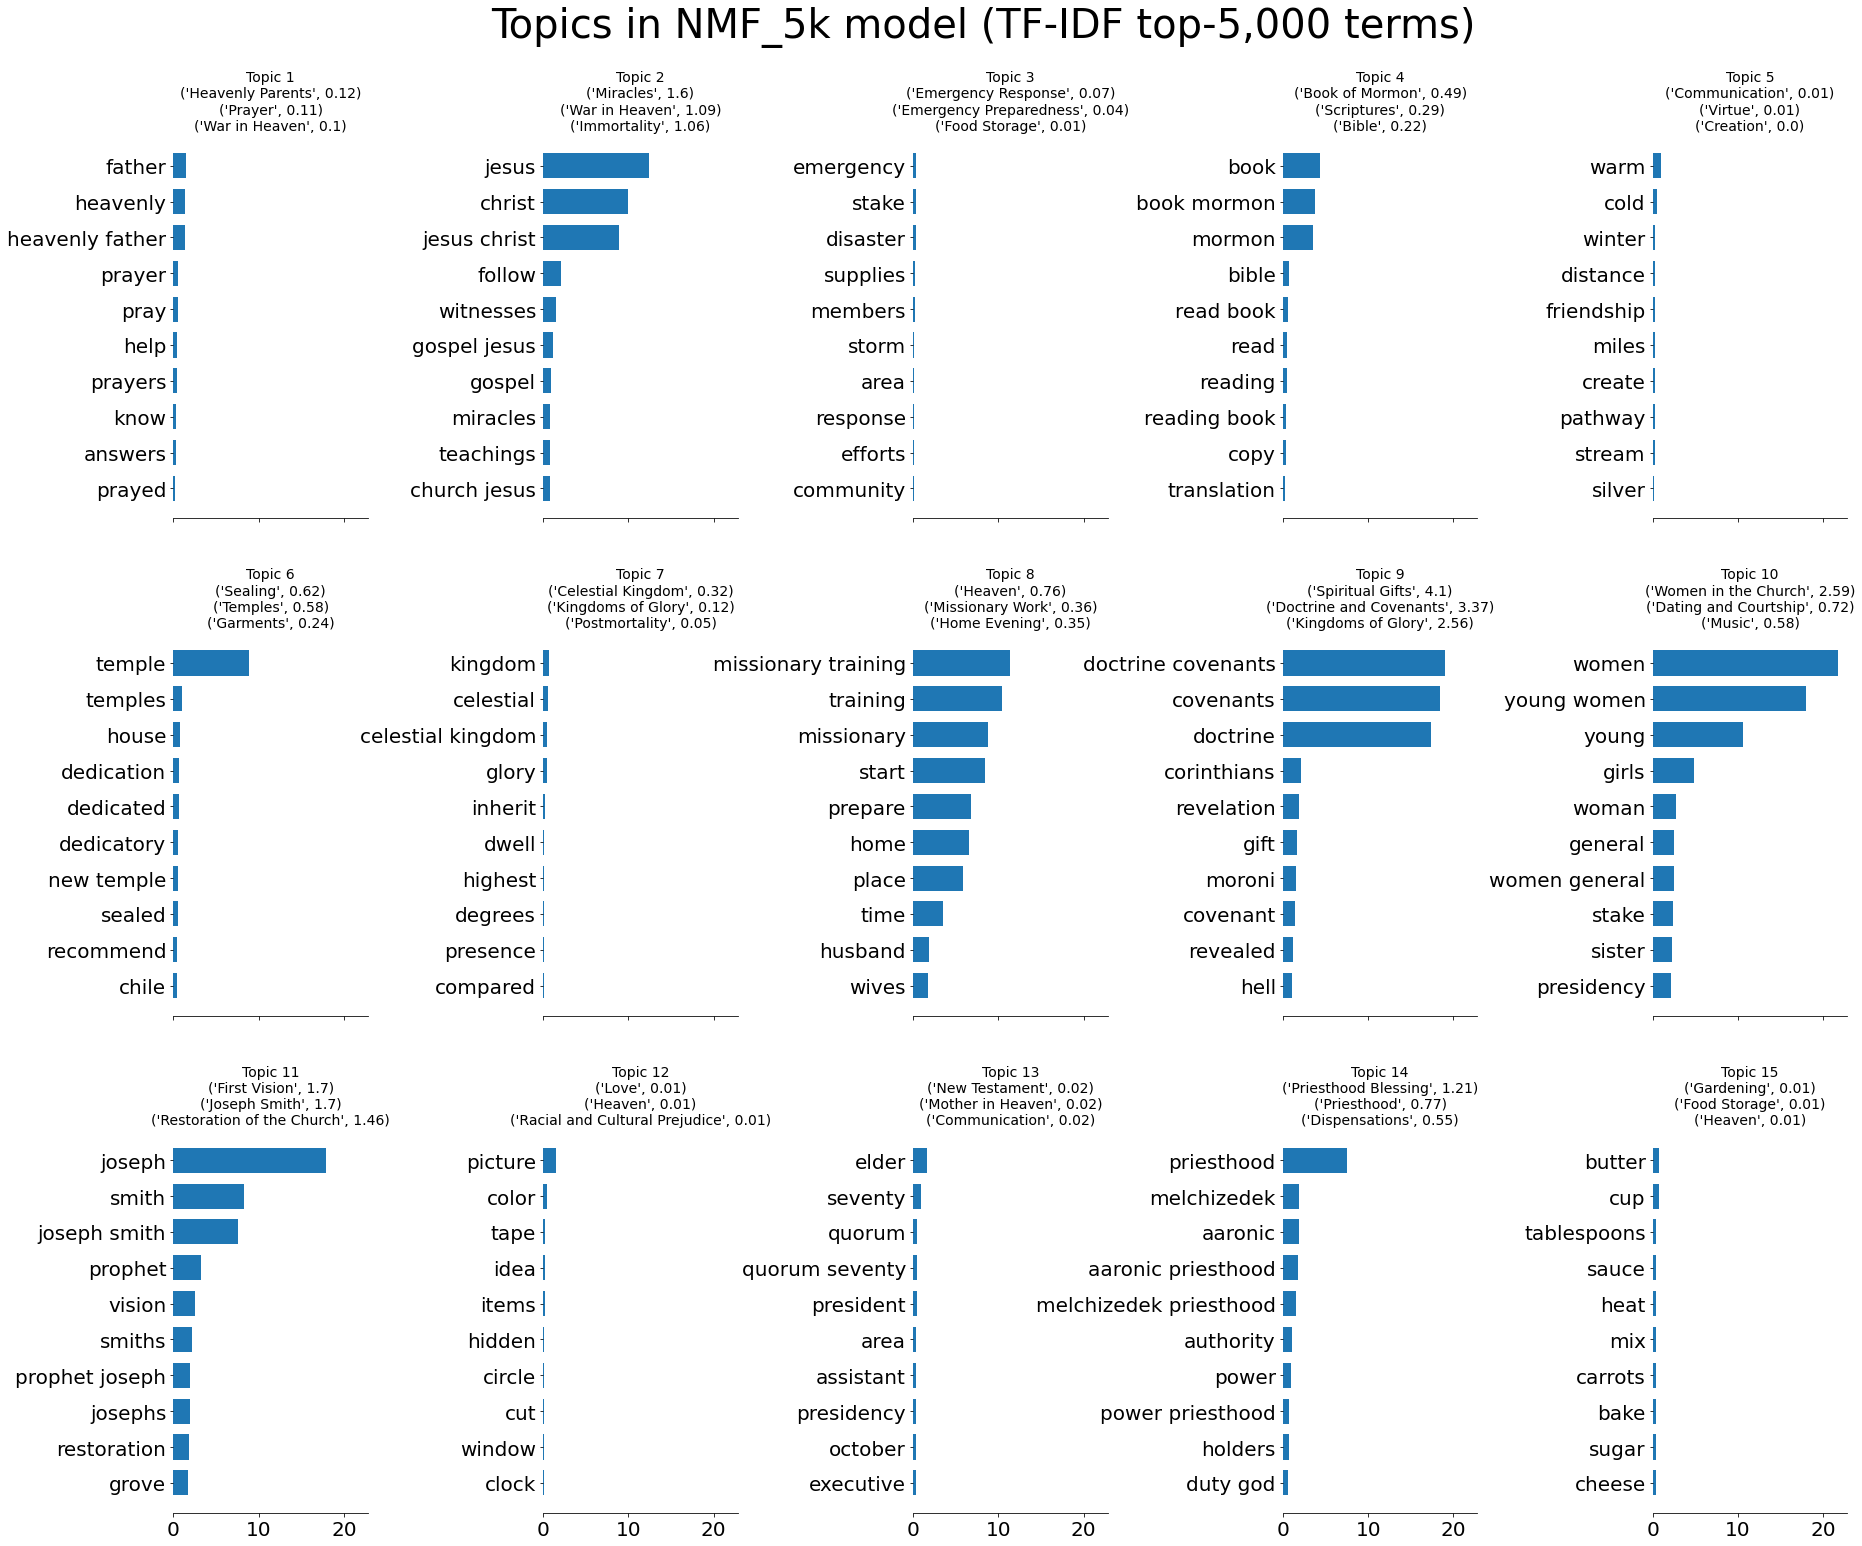

In [253]:
def plot_top_words(model, feature_names, topic_guesses, topic_labels, n_topics, n_top_words, title, randomize=False):
    cols = 5
    rows = n_topics // cols
    if rows * cols < n_topics: rows += 1
    fig, axes = plt.subplots(rows, cols, figsize=(30, 7.5 * rows), sharex=True)
    axes = axes.flatten()
    if randomize:
        idxs = random.sample(list(range(len(model.components_))), n_topics)
    else:
        idxs = [i for i in range(n_topics)]
    for topic_idx, topic in enumerate(model.components_[idxs]):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)

        label_idxs = topic_guesses[topic_idx].argsort()[: -4 : -1]
        topic_names = [topic_labels[i] for i in label_idxs]
        topic_scores = np.round(topic_guesses[topic_idx][label_idxs], 2)
        title_text = (f"Topic {topic_idx +1}\n"
                    + "\n".join([str(i) for i in zip(topic_names, topic_scores)]))
        ax.set_title(title_text, fontdict={"fontsize": 14})

        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()


plot_top_words(
    model = lda,
    feature_names = tf.get_feature_names_out(),
    topic_guesses = lda_topic_guesses,
    topic_labels = topic_df['topic'],
    n_topics = 15,
    n_top_words = 10,
    title = "Topics in LDA model (TF)",
    randomize = False)

plot_top_words(
    model = nmf,
    feature_names = tfidf.get_feature_names_out(),
    topic_guesses = nmf_topic_guesses,
    topic_labels = topic_df['topic'],
    n_topics = 15,
    n_top_words = 10,
    title = "Topics in NMF model (TF-IDF)",
    randomize = False)

plot_top_words(
    model = mini_nmf,
    feature_names = tfidf.get_feature_names_out(),
    topic_guesses = mini_nmf_topic_guesses,
    topic_labels = topic_df['topic'],
    n_topics = 15,
    n_top_words = 10,
    title = "Topics in MiniBatch NMF model (TF-IDF)",
    randomize = False)

plot_top_words(
    model = nmf_5k,
    feature_names = tfidf_5k.get_feature_names_out(),
    topic_guesses = nmf_5k_topic_guesses,
    topic_labels = topic_df['topic'],
    n_topics = 15,
    n_top_words = 10,
    title = "Topics in NMF_5k model (TF-IDF top-5,000 terms)",
    randomize = False)

### Save DataFrame with top labels for each topic

In [267]:
top3labels_lda = pd.DataFrame(
    data = lda_topic_guesses.argsort()[:, : -4 : -1],
    columns = ['lda_label1', 'lda_label2', 'lda_label3'],
    index = topic_df.index
).apply(
    lambda s: pd.Series([topic_df['topic'].values[i] for i in s],
        index = ['lda_label1', 'lda_label2', 'lda_label3']),
    axis = 1)
temp_scores = lda_topic_guesses.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3labels_lda = top3labels_lda.join(
    pd.DataFrame(
        data = temp_scores,
        columns = ['lda_score1', 'lda_score2', 'lda_score3'],
        index = topic_df.index
    )
)
top3labels_lda.to_csv('experiments/lda_topic_labels.csv', index=False)


top3labels_nmf = pd.DataFrame(
    data = nmf_topic_guesses.argsort()[:, : -4 : -1],
    columns = ['nmf_label1', 'nmf_label2', 'nmf_label3'],
    index = topic_df.index
).apply(
    lambda s: pd.Series([topic_df['topic'].values[i] for i in s],
        index = ['nmf_label1', 'nmf_label2', 'nmf_label3']),
    axis = 1)
temp_scores = nmf_topic_guesses.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3labels_nmf = top3labels_nmf.join(
    pd.DataFrame(
        data = temp_scores,
        columns = ['nmf_score1', 'nmf_score2', 'nmf_score3'],
        index = topic_df.index
    )
)
top3labels_nmf.to_csv('experiments/nmf_topic_labels.csv', index=False)


top3labels_mini_nmf = pd.DataFrame(
    data = mini_nmf_topic_guesses.argsort()[:, : -4 : -1],
    columns = ['mini_nmf_label1', 'mini_nmf_label2', 'mini_nmf_label3'],
    index = topic_df.index
).apply(
    lambda s: pd.Series([topic_df['topic'].values[i] for i in s],
        index = ['mini_nmf_label1', 'mini_nmf_label2', 'mini_nmf_label3']),
    axis = 1)
temp_scores = mini_nmf_topic_guesses.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3labels_mini_nmf = top3labels_mini_nmf.join(
    pd.DataFrame(
        data = temp_scores,
        columns = ['mini_nmf_score1', 'mini_nmf_score2', 'mini_nmf_score3'],
        index = topic_df.index
    )
)
top3labels_mini_nmf.to_csv('experiments/mini_nmf_topic_labels.csv', index=False)


top3labels_nmf_5k = pd.DataFrame(
    data = nmf_5k_topic_guesses.argsort()[:, : -4 : -1],
    columns = ['nmf_5k_label1', 'nmf_5k_label2', 'nmf_5k_label3'],
    index = topic_df.index
).apply(
    lambda s: pd.Series([topic_df['topic'].values[i] for i in s],
        index = ['nmf_5k_label1', 'nmf_5k_label2', 'nmf_5k_label3']),
    axis = 1)
temp_scores = nmf_5k_topic_guesses.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3labels_nmf_5k = top3labels_nmf_5k.join(
    pd.DataFrame(
        data = temp_scores,
        columns = ['nmf_5k_score1', 'nmg_5k_score2', 'nmg_5k_score3'],
        index = topic_df.index
    )
)
top3labels_nmf_5k.to_csv('experiments/nmf_5k_topic_labels.csv', index=False)


### Assign topics to documents

In [262]:
lda_doc_topics = lda.transform(dtm_tf[:-num_topics])
top3_lda = pd.DataFrame(
    data = lda_doc_topics.argsort()[:, : -4 : -1],
    columns = ['lda1', 'lda2', 'lda3'],
    index = sample_df_full.index
).apply(
    lambda s: pd.Series([lda_topic_names[i] for i in s.values],
        index=['lda1', 'lda2', 'lda3']),
    axis = 1)


nmf_doc_topics = nmf.transform(dtm_tfidf[:-num_topics])
top3_nmf = pd.DataFrame(
    data = nmf_doc_topics.argsort()[:, : -4 : -1],
    columns = ['nmf1', 'nmf2', 'nmf3'],
    index = sample_df_full.index
).apply(
    lambda s: pd.Series([nmf_topic_names[i] for i in s.values],
        index=['nmf1', 'nmf2', 'nmf3']),
    axis = 1)


mini_nmf_doc_topics = mini_nmf.transform(dtm_tfidf[:-num_topics])
top3_mini_nmf = pd.DataFrame(
    data = mini_nmf_doc_topics.argsort()[:, : -4 : -1],
    columns = ['mini_nmf1', 'mini_nmf2', 'mini_nmf3'],
    index = sample_df_full.index
).apply(
    lambda s: pd.Series([mini_nmf_topic_names[i] for i in s.values],
        index=['mini_nmf1', 'mini_nmf2', 'mini_nmf3']),
    axis = 1)


nmf_5k_doc_topics = nmf_5k.transform(dtm_tfidf_5k[:-num_topics])
top3_nmf_5k = pd.DataFrame(
    data = nmf_5k_doc_topics.argsort()[:, : -4 : -1],
    columns = ['nmf_5k_1', 'nmf_5k_2', 'nmf_5k_3'],
    index = sample_df_full.index
).apply(
    lambda s: pd.Series([nmf_topic_names[i] for i in s.values],
        index=['nmf_5k_1', 'nmf_5k_2', 'nmf_5k_3']),
    axis = 1)


# Create DataFrames with the scores of the top 3 categories
temp_scores = lda_doc_topics.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3_scores_lda = pd.DataFrame(
    data = temp_scores,
    columns = ['lda_score1', 'lda_score2', 'lda_score3'],
    index = sample_df_full.index)

temp_scores = nmf_doc_topics.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3_scores_nmf = pd.DataFrame(
    data = temp_scores,
    columns = ['nmf_score1', 'nmf_score2', 'nmf_score3'],
    index = sample_df_full.index)

temp_scores = mini_nmf_doc_topics.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3_scores_mini_nmf = pd.DataFrame(
    data = temp_scores,
    columns = ['mini_nmf_score1', 'mini_nmf_score2', 'mini_nmf_score3'],
    index = sample_df_full.index)

temp_scores = nmf_5k_doc_topics.copy()
temp_scores.sort()
temp_scores = temp_scores[:, : -4 : -1]
top3_scores_nmf_5k = pd.DataFrame(
    data = temp_scores,
    columns = ['nmf_5k_score1', 'nmf_5k_score2', 'nmf_5k_score3'],
    index = sample_df_full.index)

# Combine into a single DataFrame
sample_df_full = sample_df_full.join(
    [
        top3_lda,
        top3_scores_lda,
        top3_nmf,
        top3_scores_nmf,
        top3_mini_nmf,
        top3_scores_mini_nmf,
        top3_nmf_5k,
        top3_scores_nmf_5k
    ]
)

sample_df_full.head(5)

violation: 1.0
violation: 0.8762401886936607
violation: 0.1273331557279674
violation: 0.0511004928652162
violation: 0.017132977985068288
violation: 0.006452942058229549
violation: 0.003455990409721748
violation: 0.001729607060467487
violation: 0.0007749375107091339
violation: 0.00038604040303648053
violation: 0.00022511177146774836
violation: 0.00011922370945151732
violation: 5.740986628245949e-05
Converged at iteration 14
violation: 1.0
violation: 0.8060513459407618
violation: 0.07191873958043567
violation: 0.018807534967831042
violation: 0.0066910618677336045
violation: 0.0028594685644853335
violation: 0.0010535615024101993
violation: 0.000495448317869296
violation: 0.00023496210711105537
violation: 9.897607578414332e-05
Converged at iteration 11


,url,text,naive_tf1,naive_tf2,naive_tf3,naive_tf_score1,naive_tf_score2,naive_tf_score3,naive_tfidf1,naive_tfidf2,...,mini_nmf3,mini_nmf_score1,mini_nmf_score2,mini_nmf_score3,nmf_5k_1,nmf_5k_2,nmf_5k_3,nmf_5k_score1,nmf_5k_score2,nmf_5k_score3
57430,https://www.churchofjesuschrist.org/study/frie...,Our mom made temple cards from the temple pict...,Sealing,Temples,Garments,0.438,0.434,0.231,Temples,Sealing,...,Single-Parent Families,0.409,0.035,0.031,Food Storage,Sealing,Christmas,0.217,0.040,0.037
1971,https://www.churchofjesuschrist.org/study/liah...,"In “The Family: A Proclamation to the World,” ...",Single-Parent Families,Family History,Family,0.247,0.199,0.196,Single-Parent Families,Transgender,...,Soul,0.368,0.007,0.005,Food Storage,Love,Miracles,0.331,0.025,0.009
8299,https://www.churchofjesuschrist.org/study/liah...,"Saturday Morning, October 4, 2008, General Ses...",Music,Virtue,Addiction,0.929,0.702,0.664,Music,Virtue,...,Service,0.209,0.115,0.042,Hope,Foreordination,Communication,0.256,0.108,0.071
63503,https://www.churchofjesuschrist.org/study/frie...,"To find the names of colors you know,\nChange ...",Heaven,Articles of Faith,Profanity,0.040,0.036,0.032,Profanity,Articles of Faith,...,Articles of Faith,0.164,0.130,0.068,Fasting and Fast Offerings,Priesthood Blessing,Missionary Work,0.156,0.085,0.039
12976,https://www.churchofjesuschrist.org/study/liah...,"To make this marble game, you will need: a car...",New Testament,Profanity,Hell,0.118,0.056,0.054,New Testament,Celestial Kingdom,...,Priesthood Blessing,0.241,0.049,0.016,Family Councils,Transgender,Family Councils,0.113,0.019,0.013


In [264]:
sample_df_full.to_csv('experiments/topic_model_methods.csv', index=False)

In [228]:
# Examine distribution of assigned topics

# Note that some of the topics argmaxed to the same topic label, which
# is why these counts look different than the ones in common_topics above.
print(f"Total number of topics assigned: {len(sample_df_full['nmf1'].unique())}/{num_topics} possible topics.")
sample_df_full[['url', 'nmf_label1']].groupby(by='nmf_label1').count().sort_values(by='url', ascending=False)

Total number of topics assigned: 148/161 possible topics.


,url
nmf_label1,
Atonement of Jesus Christ,31
Temptation,28
Baptism,21
Celestial Kingdom,21
Addiction,20
...,...
Ordinances,1
Paradise,1
Plan of Salvation,1


# Experiment: Topic visualization with `pyLDAvis`

What I learned:
- Some preprocessing may be necessary (e.g., removing digits, expanding contractions like _we're_ to _we are_)
- Normalizing terms through TF-IDF performs worse than standard term counts; possibly because so many of the documents reference related information, since the magazines share a common topic: Christianity. TF-IDF appears to overweight noise in the dataset (like numbers)
- NMF appears to perform much better than LDA at generating perceptually good topics (i.e., topics are distinct from one another and words within a topic are related)

Import required packages for this section

In [ ]:
# Built-in packages
import re                       # text-based pattern matching
import unicodedata              # Unicode character reference (database on character properties)
                                # for normalizing characters. See also unicodedata2: https://pypi.org/project/unicodedata2/
# import unidecode                # Normalizing (transliterating) unicode to ascii; third-party package

# Third-party packages
import numpy as np              # array-based data storage and computation
import pandas as pd             # tabular data analysis
import pyLDAvis                 # visualization for LDA topics

# Scikit-Learn classes
from sklearn.feature_extraction.text import CountVectorizer     
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF, MiniBatchNMF

# Explanation of sklearn imports
# ``````````````````````````````
# CountVectorizer: Convert documents (text strings) to vectors 
# representing the number of times a word or n-gram 
# appeared in each document

# TfidfVectorizer: Convert documents to vectors representing the number
# of times a normalized word or n-gram appeared in each document
# where words are normalized by Term-frequency x Inverse-document-frequency

# LatentDirichletAllocation: Assign topics to documents after the 
# documents have been processed into vectors (i.e., the document-term matrix 
# output by CountVectorizer or TfidfVectorizer)

# NMF and MiniBatchNMF: Assign topics to documents after the documents 
# have been processed and normalized (i.e., by TfidfVectorizer). Time
# complexity increases in polynomial time with respect to the number
# of inputs, so the MiniBatchNMF can perform much faster for large datasets.

# set_config: Disable HTML display of sklearn objects;
# this way, the text representation is returned
# when an object's __repr__ method is called, like
# when that object is on the last line in a code cell.
from sklearn import set_config
set_config(display='text')

In [ ]:
# Set the number of words to include in n-grams (e.g., 2 for bigrams)
NGRAMS = 2
MAX_DOC_FREQ = 0.5
MIN_DOC_FREQ = 0.02

count_vectorizer = CountVectorizer(
    strip_accents = 'unicode',
    ngram_range = (1, NGRAMS),
    max_df = MAX_DOC_FREQ,
    min_df = MIN_DOC_FREQ,
    stop_words='english'
)

tfidf_vectorizer = TfidfVectorizer(**count_vectorizer.get_params())

In [ ]:
sample_df = pd.read_csv('data/article_text.csv').dropna().sample(n=1000, random_state=0)

In [ ]:
sample_df.isna().sum()

url     0
text    0
dtype: int64

In [ ]:
import time
t0 = time.perf_counter()

doc_terms_matrix = count_vectorizer.fit_transform(sample_df['text'])
t1 = time.perf_counter()

tfidf_doc_terms_matrix = tfidf_vectorizer.fit_transform(sample_df['text'])
t2 = time.perf_counter()

print(f"Time for CountVectorizer: {t1-t0:.6f}s")
print(f"Time for TfidfVectorizer: {t2-t1:.6f}s")

c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:2029: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. <class 'numpy.int64'> 'dtype' will be converted to np.float64.
  warnings.warn(


Time for CountVectorizer: 2.948595s
Time for TfidfVectorizer: 3.327715s


In [ ]:
doc_terms_matrix.shape

(1000, 2557)

In [ ]:
tfidf_doc_terms_matrix.shape

(1000, 2557)

Latent Dirichlet Allocation for standard word counts (doc-terms matrix from CountVectorizer)

In [ ]:
lda_tf = LatentDirichletAllocation(
    n_components=10,
    learning_method='online',
    n_jobs=-1,
    max_iter=20,
    random_state=0)
lda_tf.fit(doc_terms_matrix)

LatentDirichletAllocation(learning_method='online', max_iter=20, n_jobs=-1,
                          random_state=0)

In [ ]:
for i, topic in enumerate(lda_tf.components_):
    words = [count_vectorizer.get_feature_names_out()[j] for j in topic.argsort()[-10:]]
    print(f"Top words for topic {i}: {words}")

Top words for topic 0: ['don', 'father', 'little', 'know', 'good', 'mom', 'didn', 'like', 'just', 'said']
Top words for topic 1: ['people', 'world', 'gospel', 'faith', 'know', 'things', 'love', 'life', 'lord', 'god']
Top words for topic 2: ['hymn', 'president thomas', 'general conference', 'thomas monson', 'general', 'thomas', 'monson', 'hymns', 'music', 'conference']
Top words for topic 3: ['missionary', 'stake', 'says', 'ward', 'members', 'president', 'quorum', 'missionaries', 'mission', 'elder']
Top words for topic 4: ['saints', 'new', 'salt lake', 'president', 'lake', 'city', 'salt', 'people', 'members', 'temple']
Top words for topic 5: ['pray', 'page', 'feel', 'help', 'picture', 'usa', 'paper', 'age', 'like', 'friend']
Top words for topic 6: ['youth', 'young women', 'relief society', 'men', 'society', 'relief', 'president', 'women', 'young', 'priesthood']
Top words for topic 7: ['president', 'home', 'said', 'father', 'brother', 'years', 'lord', 'smith', 'young', 'joseph']
Top word

In [ ]:
import pyLDAvis.sklearn
pyLDAvis.display(pyLDAvis.sklearn.prepare(lda_tf, doc_terms_matrix, count_vectorizer))

c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Ryan\anaconda3\lib\site-packages\pyLDAvis\_prepare.py:246: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(


In [ ]:
# Using the tSNE visualization rather than the default PCoA
pyLDAvis.display(pyLDAvis.sklearn.prepare(lda_tf, doc_terms_matrix, count_vectorizer, mds='tsne'))

c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Ryan\anaconda3\lib\site-packages\pyLDAvis\_prepare.py:246: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(
c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:819: FutureWarning: 'square

Latent Dirichlet Allocation using Term-Frequency Inverse-Document-Frequency (doc-terms matrix from TfidfVectorizer)

In [ ]:
lda_tfidf = LatentDirichletAllocation(
    n_components=10,
    learning_method='online',
    n_jobs=-1,
    max_iter=20,
    random_state=0)
lda_tfidf.fit(tfidf_doc_terms_matrix)

LatentDirichletAllocation(learning_method='online', max_iter=20, n_jobs=-1,
                          random_state=0)

In [ ]:
for i, topic in enumerate(lda_tfidf.components_):
    print(f"Top words for topic {i}:")
    print([tfidf_vectorizer.get_feature_names_out()[j] for j in topic.argsort()[-10:]])

Top words for topic 0:
['help', 'temple', 'life', 'children', 'jesus', 'father', 'said', 'lord', 'god', 'family']
Top words for topic 1:
['today', 'peace', 'know', 'girl', 'ward', 'names', 'share gospel', 'long time', 'eternity', 'answers']
Top words for topic 2:
['choose', 'children', 'priesthood', 'inside', 'liahona', 'david', 'sunday', 'man', 'family', 'hymns']
Top words for topic 3:
['felt', 'abraham', 'youth', 'family', 'know', 'dad', 'friends', 'said', 'grandma', 'mom']
Top words for topic 4:
['christ', 'gave', 'block', 'discover', 'way', 'open', 'temple', 'commandment', 'jesus', '00']
Top words for topic 5:
['children', 'missionaries', 'gospel', 'paper', 'picture', 'circle', 'utah', 'items', 'hidden', 'ages']
Top words for topic 6:
['like', 'jesus', 'set', 'read', 'things', 'life', 'words', 'gifts', 'said', 'father']
Top words for topic 7:
['100', 'bright', 'hymns', 'president', 'words', 'just', 'spanish', 'english', 'class', 'letter']
Top words for topic 8:
['large', 'council',

In [ ]:
pyLDAvis.display(pyLDAvis.sklearn.prepare(lda_tfidf, tfidf_doc_terms_matrix, tfidf_vectorizer))

c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Ryan\anaconda3\lib\site-packages\pyLDAvis\_prepare.py:246: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(


In [ ]:
# Visualization using tSNE rather than the default PCoA
pyLDAvis.display(pyLDAvis.sklearn.prepare(lda_tfidf, tfidf_doc_terms_matrix, tfidf_vectorizer, mds='tsne'))

c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Ryan\anaconda3\lib\site-packages\pyLDAvis\_prepare.py:246: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(
c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\Ryan\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:819: FutureWarning: 'square

# Experiment: Grid search over potential parameters
What I learned:
- For `LatentDirichletAllocation`, the algorithm seems to prefer fewer topics (i.e., the lowest `n_components` seemed to win: 20 in the first run with (20, 50, 100) as options and 10 in the second run with (10, 20) as options).
- For `LatentDirichletAllocation`, a higher `max_iter` returned a better score (I tried 10 and 20; 20 was better)
- For `CountVectorizer`, `stopwords='english'` performed better
- For `CountVectorizer`, `preprocessor=preprocess_text` performed better (i.e., my custom function to normalize the text and remove non-alphanumeric characters)
- For `CountVectorizer`, `strip_accents='unicode'` performed better
- For `CountVectorizer`, lower values of `max_df` performed better (I tried 0.5, 0.7, and 0.9, and 0.5 won)
- For `CountVectorizer`, higher values of `min_df` performed better (I tried 0.01 and 0.02 and 0.02 won)

Set up pipeline and grid search. See: [Sample pipeline for text feature extraction and evaluation](https://scikit-learn.org/stable/auto_examples/model_selection/grid_search_text_feature_extraction.html) from Scikit-Learn's examples.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import os

sample_df = pd.read_csv('data/article_text.csv').dropna().sample(n=1000, random_state=0)

pipe = Pipeline(
    [
        ("dtm", CountVectorizer()),
        ("lda", LatentDirichletAllocation())
    ],
    verbose=True
)

parameters = {
    # "dtm__strip_accents": (None, 'unicode', 'ascii'),
    "dtm__ngram_range": [(1, 2)], # (1, 3)),
    "dtm__max_df": [0.5], # (0.5, 0.7, 0.9),
    "dtm__min_df": (0.01, 0.02),
    "dtm__stop_words": ['english'], # ('english', None),
    "dtm__preprocessor": (None, preprocess_text),
    "lda__n_components": (10, 20, 50), # (20, 50, 100),
    "lda__max_iter": [20], # (10, 20),
    "lda__learning_method": ['online']
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    n_jobs=-1,
    verbose=2)

grid_search.fit(sample_df['text'])

print(f"Best score: {grid_search.best_score_:.3f}")
print("Best parameters set:")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(parameters.keys()):
    print(f"\t{param_name}: {best_parameters[param_name]}")

# Save results
test_num = 1
save_fp = f"data/grid_test_results{test_num}.csv"
while os.path.exists(save_fp):
    test_num += 1
    save_fp = f"data/grid_test_results{test_num}.csv"

pd.DataFrame(grid_search.cv_results_).to_csv(save_fp, index=False)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[Pipeline] ............... (step 1 of 2) Processing dtm, total=   3.1s
[Pipeline] ............... (step 2 of 2) Processing lda, total=  29.4s
Best score: -409941.156
Best parameters set:
	dtm__max_df: 0.5
	dtm__min_df: 0.02
	dtm__ngram_range: (1, 2)
	dtm__preprocessor: <function preprocess_text at 0x000001BF07ABF5E0>
	dtm__stop_words: english
	lda__learning_method: online
	lda__max_iter: 20
	lda__n_components: 10


In [ ]:
print(f"Best score: {grid_search.best_score_:.3f}")
print("Best parameters set:")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(parameters.keys()):
    print(f"\t{param_name}: {best_parameters[param_name]}")

Best score: -642275.409
Best parameters set:
	dtm__max_df: 0.5
	dtm__preprocessor: None
	dtm__stop_words: english
	dtm__strip_accents: unicode
	lda__learning_method: online
	lda__max_iter: 20
	lda__n_components: 20


In [ ]:
# Display HTML diagram of the grid search
# See: https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_pipeline_display.html

from sklearn import set_config
set_config(display='diagram')
grid_search

# Return to normal
set_config(display='text')

GridSearchCV(estimator=Pipeline(steps=[('dtm', CountVectorizer()),
                                       ('lda', LatentDirichletAllocation())],
                                verbose=True),
             n_jobs=-1,
             param_grid={'dtm__max_df': (0.5, 0.7, 0.9),
                         'dtm__preprocessor': (None,
                                               <function preprocess_text at 0x000001BF02F46550>),
                         'dtm__stop_words': ('english', None),
                         'dtm__strip_accents': (None, 'unicode', 'ascii'),
                         'lda__learning_method': ['online'],
                         'lda__max_iter': (10, 20),
                         'lda__n_components': (20, 50, 100)},
             verbose=2)